<!-- agrosat-cover -->
<div align="center">

<img alt="Institucion: Tec de Monterrey" src="https://img.shields.io/badge/Institucion-Tec%20de%20Monterrey-002D72">&nbsp;<img alt="Programa: MNA" src="https://img.shields.io/badge/Programa-MNA-0072CE">&nbsp;<img alt="Materia: Proyecto Integrador" src="https://img.shields.io/badge/Materia-Proyecto%20Integrador-F2A900">&nbsp;<img alt="Entregable: Avance 5" src="https://img.shields.io/badge/Entregable-Avance%205-1E40AF">

<img alt="Python: 3.12" src="https://img.shields.io/badge/Python-3.12-3776AB">&nbsp;<img alt="Jupyter: notebook" src="https://img.shields.io/badge/Jupyter-notebook-3776AB">&nbsp;<img alt="PyTorch: 2.4" src="https://img.shields.io/badge/PyTorch-2.4-3776AB">&nbsp;<img alt="Polars: 1.x" src="https://img.shields.io/badge/Polars-1.x-3776AB">

</div>

<h1 align="center">Avance 5 — Modelo final: ensambles de clasificación de cultivos</h1>
<p align="center"><strong>AgroSatCopilot</strong> · Cuantificación de superficies de cultivo por satélite</p>

<table align="center"><tr>
<td align="center" width="200"><img src="../../img/IsaacAvila.jpg" width="130" height="130" style="border-radius:50%;object-fit:contain;background:#f0f0f0"><br><strong>Carlos Isaac Ávila Gutiérrez</strong><br><code>A01796035</code><br><sub>ML / Data Scientist</sub></td>
<td align="center" width="200"><img src="../../img/AaronBocanegra.jpg" width="130" height="130" style="border-radius:50%;object-fit:contain;background:#f0f0f0"><br><strong>Carlos Aaron Bocanegra Buitrón</strong><br><code>A01796345</code><br><sub>Full-Stack / Backend</sub></td>
<td align="center" width="200"><img src="../../img/ArthurZizumbo.png" width="130" height="130" style="border-radius:50%;object-fit:contain;background:#f0f0f0"><br><strong>Arthur Jafed Zizumbo Velasco</strong><br><code>A01796363</code><br><sub>MLOps / Platform</sub></td>
</tr></table>

---

<strong>Familia de siete ensambles (Voting, Bagging, Stacking, Blending y tres incrementales) sobre los mejores modelos individuales de la fase previa, comparativa ordenada por F1-macro, elección argumentada del modelo final y figuras interpretadas sobre datos no vistos.</strong>

<table>
<tr><td><strong>Equipo 17</strong></td><td>&nbsp;&nbsp;• <strong>Carlos Isaac Ávila Gutiérrez</strong> — <code>A01796035</code><br>&nbsp;&nbsp;• <strong>Carlos Aaron Bocanegra Buitrón</strong> — <code>A01796345</code><br>&nbsp;&nbsp;• <strong>Arthur Jafed Zizumbo Velasco</strong> — <code>A01796363</code></td></tr>
<tr><td><strong>Curso</strong></td><td>MNA — Tec de Monterrey · 20-abr → 3-jul-2026</td></tr>
<tr><td><strong>Sponsor académico</strong></td><td>Dr. Gerardo Jesús Camacho González · gjcamacho@tec.mx</td></tr>
<tr><td><strong>Fecha de entrega</strong></td><td>2026-06-10</td></tr>
</table>


## Resumen ejecutivo

El problema es **clasificar el cultivo de cada parcela agrícola** a partir de imágenes de satélite Sentinel-2 multitemporales, sobre un territorio real con etiquetas de agricultores (PASTIS-R, 18 cultivos). En la fase anterior se compararon seis arquitecturas individuales de segmentación; la mejor alcanzó un F1-macro de 0,625 a nivel parcela. Esta fase **combina los modelos** para superar ese techo.

Se construye una familia de **siete ensambles** que cubre las dos grandes estrategias del aprendizaje por ensamble:

| Estrategia | Ensamble | Qué combina |
|------------|----------|-------------|
| **Homogénea** | Voting (píxel) | promedio de probabilidades de tres modelos densos |
| **Homogénea** | Bagging (parcela) | varios XGBoost sobre remuestreos del embedding satelital |
| **Heterogénea** | **Stacking (parcela)** | meta-modelo sobre modelos temporales + tabular |
| **Heterogénea** | Blending (parcela) | mezcla convexa de pesos optimizados |
| Incremental | + rama contrastiva fenológica | añade una vista visión-lenguaje |
| Incremental | + embedding satelital multianual | añade un resumen espectral estable |
| Incremental | + contexto geográfico (diseño) | clima, relieve y vecindad (trabajo futuro) |

**Resultado**: el **Stacking heterogéneo** es el modelo final, con **F1-macro 0,749** a nivel parcela sobre datos no vistos — **+12 puntos** sobre el mejor modelo individual. La lección central es que un meta-modelo que aprende a combinar fortalezas complementarias (la forma temporal del cultivo + un resumen espectral aprendido) supera a cualquier modelo por sí solo, y lo hace con un costo de inferencia despreciable.

## Objetivos

- Mejorar significativamente el rendimiento aprovechando las fortalezas de distintos modelos y reduciendo sus debilidades.
- Evaluar la calidad de las predicciones sobre **datos no vistos**.

> **Rigor metodológico (transversal)**: todas las métricas se reportan sobre un **fold espacial reservado** que ningún modelo vio al entrenar; las probabilidades que alimentan los ensambles son **out-of-fold** (sin fuga de información); el meta-modelo del stacking se valida con **validación cruzada espacial** y aborta si detecta solapamiento entre entrenamiento y evaluación. Sin estas garantías, una mejora de ensamble no sería creíble.

In [1]:
# --- Colab + team shared Drive setup ---
import os, subprocess, sys
from pathlib import Path

# Mount Drive and prefix paths with shared_folder_path (empty when local).
_IN_COLAB = False
shared_folder_path = ''
try:
    from google.colab import drive
    drive.mount('/content/drive')
    shared_folder_path = '/content/drive/MyDrive/Integrador/'
    _IN_COLAB = True
except ImportError:
    pass

# Integrator notebook: it only consolidates CSV/figures from reports/ and does NOT
# import repo code, so it runs end to end anywhere the artifacts are present.
_search = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
if _IN_COLAB:
    _search = [Path('/content/agrosat-copilot'), *_search]
for _cand in _search:
    if (_cand / 'pyproject.toml').is_file():
        os.chdir(_cand)
        break

if _IN_COLAB:
    subprocess.run([sys.executable, '-m', 'pip', '-q', 'install', 'polars'], check=False)

import matplotlib.pyplot as plt
import polars as pl
from IPython.display import Image, Markdown, display

_PREFIX = shared_folder_path if shared_folder_path else ''
METRICS = Path(_PREFIX + 'reports/ensemble/metrics')
FIGURES = Path(_PREFIX + 'reports/ensemble/figures')

def show_csv(name, *, sort=None, descending=True, round_cols=None):
    """Load and display a metrics CSV; return the DataFrame (empty if missing)."""
    p = METRICS / name
    if not p.is_file():
        display(Markdown(f'> _Pendiente: falta `{p}`._'))
        return pl.DataFrame()
    df = pl.read_csv(p, infer_schema_length=None)
    if round_cols:
        df = df.with_columns([pl.col(c).round(4) for c in round_cols if c in df.columns])
    if sort and sort in df.columns:
        df = df.sort(sort, descending=descending)
    return df

def show_fig(rel_path, caption=None):
    """Display a figure under reports/ensemble/figures with an optional caption."""
    p = FIGURES / rel_path
    if not p.is_file():
        display(Markdown(f'> _Pendiente: falta la figura `{p}`._'))
        return
    display(Image(filename=str(p)))
    if caption:
        display(Markdown(f'*{caption}*'))

def show_phenology(slug, *, top=6):
    """Display the NDVI-derived phenology that supports the prediction per parcel."""
    p = METRICS / f'inference_fenologia_{slug}.csv'
    if not p.is_file():
        display(Markdown(f'> _Pendiente: falta `{p}`._'))
        return
    df = pl.read_csv(p)
    for escena in df['escena'].unique(maintain_order=True).to_list():
        sub = df.filter(pl.col('escena') == escena).head(top)
        lines = [f'**Escena {escena}** — fenología (curva NDVI por parcela) que apoya la predicción:', '']
        for r in sub.iter_rows(named=True):
            ok = 'acierto' if r['acierto'] else 'error'
            lines.append(
                f"- **{r['clase_predicha']}** (real: {r['clase_real']}, {ok}, "
                f"pico NDVI {r['ndvi_pico']}): {r['fenologia']}")
        display(Markdown(chr(10).join(lines)))

print('repo:', Path.cwd(), '| colab:', _IN_COLAB, '| artefactos:', _PREFIX or '(local)')

repo: C:\Users\arthu\Proyectos\MNA\agro_sat_copilot | colab: False | artefactos: (local)


## Metodología

- **Datos**: PASTIS-R (Francia metropolitana), 2 433 imágenes Sentinel-2 multitemporales de 128x128 píxeles con etiquetas reales por parcela. **18 cultivos** con fuerte desbalance (la clase más común, prado, es ~30 veces más frecuente que la más rara).
- **Datos no vistos**: el conjunto se parte en folds **espacialmente disjuntos**. Un fold se **reserva** por completo (held-out) y es donde se reporta TODA métrica; ningún modelo ni meta-modelo lo vio. Esto evita que parcelas vecinas filtren información entre entrenamiento y prueba.
- **Probabilidades out-of-fold**: cada modelo base entrega, para las parcelas del fold reservado, probabilidades **post-softmax** (no puntajes crudos) generadas sin haber visto esas parcelas. Son la materia prima de los ensambles.
- **Reconciliación píxel - parcela**: los modelos densos predicen por píxel; se agregan a **probabilidad por parcela** (promedio dentro de la geometría, renormalizado) para alinear todos los miembros en el mismo nivel.
- **Métricas**: **F1-macro** (principal, justa bajo desbalance porque pesa igual a cada cultivo), **accuracy** y **costo de inferencia**. Se reporta también la **ganancia** de cada ensamble frente al mejor modelo individual.
- **Optimización de hiperparámetros**: Optuna en los ensambles que lo requieren (número de bolsas y árbol en bagging; pesos de la mezcla en blending).

## El conjunto completo del ensamble y sus miembros

Antes de comparar números conviene entender **qué es** el ensamble ganador y **de qué está hecho**. El modelo final no es un único modelo grande: es un **comité** de modelos especialistas cuyas opiniones combina un árbitro aprendido (el meta-modelo). Cada miembro mira el mismo cultivo desde un ángulo distinto, y ahí está su valor.

### Los miembros del ensamble (qué aporta cada uno)

| Miembro | Familia | Qué ve del cultivo | Rol en el comité |
|---------|---------|--------------------|------------------|
| **TSViT-pheno** | Transformer temporal | la **forma de la curva temporal** completa (cómo verdea y madura a lo largo del año) | voz principal: la fenología es la señal que más separa cultivos |
| **U-TAE** | Atención temporal sobre U-Net | la **dinámica temporal** con foco espacial fino en bordes de parcela | segunda opinión temporal, decorrelacionada de TSViT |
| **XGBoost sobre AlphaEarth** | Tabular sobre embedding de fundación | un **resumen espectral anual aprendido** (64 dimensiones) por parcela | voz no temporal: aporta donde la forma temporal es ambigua |
| **Rama contrastiva (FarSLIP)** | Visión-lenguaje por parcela | la parcela descrita por su **descripción fenológica** (texto sobre su curva NDVI) | vista alternativa texto-imagen, miembro incremental |

### Cómo se combinan (el árbitro)

- En el **Stacking**, un **meta-modelo** (una regresión logística balanceada) recibe las probabilidades de cada miembro por clase y **aprende a cuánto creerle a cada uno según la clase**. No es un promedio: si en los cereales de invierno el tabular suele acertar y los temporales dudan, el meta-modelo aprende a pesar más al tabular ahí. Ese árbitro se entrena **solo sobre probabilidades out-of-fold**, nunca sobre los datos de prueba.
- En el **Blending**, en vez de un árbitro entrenado, se buscan con Optuna los **pesos fijos** (que suman uno) de una mezcla lineal que maximiza el F1 sobre un conjunto de validación espacialmente separado.

La diferencia es clave y reaparece en los resultados: el árbitro del stacking puede dar **pesos distintos por clase**; el blending da **un peso global** por miembro. Por eso, cuando se añade un miembro más débil, el stacking lo sabe sub-ponderar donde estorba, y el blending no.

## Las cuatro estrategias de ensamble

Se generan **siete** ensambles. Los cuatro primeros son las estrategias clásicas y cubren **ambas** familias; los tres últimos son incrementales, que añaden señales nuevas sobre el mejor ensamble.

**Homogéneas** (combinan variantes del mismo tipo de modelo):

- **Voting (píxel)**: promedia las probabilidades de tres modelos densos y toma la clase más votada. Simple y sin entrenamiento extra, pero arrastra a los miembros débiles y opera píxel a píxel (lento).
- **Bagging (parcela)**: entrena varios XGBoost sobre **remuestreos bootstrap** del embedding satelital y promedia. El número de bolsas y la profundidad se afinan con Optuna. Reduce varianza pero no crea diversidad de enfoque.

**Heterogéneas** (combinan modelos de naturaleza distinta — es donde está la señal):

- **Stacking (parcela)**: el comité con árbitro aprendido descrito arriba, entrenado **solo sobre probabilidades out-of-fold** con validación cruzada espacial.
- **Blending (parcela)**: la mezcla convexa de pesos fijos optimizada con Optuna.

> Para stacking y blending se usan **los mejores modelos individuales de la fase previa** (el mejor encoder temporal + la atención temporal + el mejor tabular).

In [2]:
# Four base strategies on the held-out fold (unseen data), sorted by the main
# metric (F1-macro). Includes the best individual model as reference.
base = show_csv('comparison_us040.csv', sort='f1_macro',
                round_cols=['f1_macro', 'accuracy', 'inference_time_s'])
if base.height:
    display(base.rename({
        'model': 'modelo', 'inference_time_s': 'tiempo_inferencia_s',
        'chosen': 'elegido'}))
base

modelo,f1_macro,accuracy,tiempo_inferencia_s,elegido
str,f64,f64,f64,bool
"""E3 Stacking (parcela)""",0.747,0.849,0.0424,true
"""E4 Blending (parcela)""",0.7414,0.8618,0.0064,false
"""TSViT-pheno (individual)""",0.6253,NaN,NaN,false
"""E1 Voting (pixel)""",0.6225,0.809,42.4885,false
"""E2 Bagging (parcela)""",0.5864,0.7816,5.4966,false


model,f1_macro,accuracy,inference_time_s,chosen
str,f64,f64,f64,bool
"""E3 Stacking (parcela)""",0.747,0.849,0.0424,true
"""E4 Blending (parcela)""",0.7414,0.8618,0.0064,false
"""TSViT-pheno (individual)""",0.6253,NaN,NaN,false
"""E1 Voting (pixel)""",0.6225,0.809,42.4885,false
"""E2 Bagging (parcela)""",0.5864,0.7816,5.4966,false


**Lectura de las cuatro estrategias base**:

- Las **heterogéneas ganan con claridad**: Stacking (0,747) y Blending (0,741) superan por más de 10 puntos a las homogéneas, Voting (0,623) y Bagging (0,586). Combinar modelos de naturaleza distinta aporta mucho más que combinar variantes del mismo modelo.
- Ambas heterogéneas **superan al mejor individual** (0,625): el ensamble cumple su promesa.
- El **Bagging** es el más débil: remuestrear un solo tipo de modelo (tabular) no crea diversidad de enfoque; confirma que la fuerza está en la heterogeneidad.
- El **Voting** es además el más lento (opera por píxel), lo que lo descarta para producción aunque su F1 fuera competitivo.

## Los tres ensambles incrementales

Sobre el mejor ensamble se prueba, de forma **honesta**, si señales adicionales aportan:

- **+ rama contrastiva fenológica**: añade la vista visión-lenguaje (el modelo que aprende a describir la dinámica del cultivo). Se prueba como miembro extra del stacking y del blending.
- **+ embedding satelital multianual**: promedia el resumen espectral de dos años para reducir el ruido de un año puntual.
- **+ contexto geográfico**: clima, relieve y vecindad espacial. La rama tabular (clima, relieve) ya se descartó por evidencia previa; el único eje sin medir, la **vecindad espacial estructural**, se prueba ahora en su versión más barata (E-c LIGHT, más abajo) y resulta en un **resultado nulo honesto**: tampoco mejora al campeón, porque el embedding satelital ya absorbe ese contexto.

In [3]:
# Incremental ensembles: the contrastive phenology branch crossed with
# stacking/blending and 3-vs-5 members, over two temporal bases.
grid = show_csv('us043_farslip_grid.csv', sort='f1_macro',
                round_cols=['f1_macro', 'accuracy', 'delta_farslip'])
if grid.height:
    display(grid.rename({'modelo': 'configuracion', 'delta_farslip': 'delta_vs_base'}))
grid

configuracion,f1_macro,accuracy,delta_vs_base
str,f64,f64,f64
"""Stacking-5 (+FarSLIP) | tsvit-…",0.7486,0.8495,0.0016
"""Stacking-3 | tsvit-pheno (camp…",0.747,0.849,0.0
"""Blending-3 | tsvit-pheno (camp…",0.7436,0.8629,0.0
"""Blending-5 (+FarSLIP) | tsvit-…",0.7319,0.8594,-0.0117
"""Stacking-5 (+FarSLIP) | tsvit-…",0.6477,0.7935,0.0118
"""Stacking-3 | tsvit-pheno-fullm…",0.6359,0.7877,0.0
"""Blending-5 (+FarSLIP) | tsvit-…",0.5866,0.7864,0.0215
"""Blending-3 | tsvit-pheno-fullm…",0.5651,0.7697,0.0


modelo,f1_macro,accuracy,delta_farslip
str,f64,f64,f64
"""Stacking-5 (+FarSLIP) | tsvit-…",0.7486,0.8495,0.0016
"""Stacking-3 | tsvit-pheno (camp…",0.747,0.849,0.0
"""Blending-3 | tsvit-pheno (camp…",0.7436,0.8629,0.0
"""Blending-5 (+FarSLIP) | tsvit-…",0.7319,0.8594,-0.0117
"""Stacking-5 (+FarSLIP) | tsvit-…",0.6477,0.7935,0.0118
"""Stacking-3 | tsvit-pheno-fullm…",0.6359,0.7877,0.0
"""Blending-5 (+FarSLIP) | tsvit-…",0.5866,0.7864,0.0215
"""Blending-3 | tsvit-pheno-fullm…",0.5651,0.7697,0.0


**Lectura de los incrementales (el hallazgo no obvio)**:

- La rama contrastiva, **añadida vía stacking** sobre la mejor base, mejora levemente al campeón (de 0,747 a **0,749**): el meta-modelo le da un peso pequeño pero no la descarta.
- **Añadida vía blending, perjudica** (de 0,744 a 0,732): mezclar con un peso global fijo deja que un miembro más débil contamine la decisión. La lección es **meter la señal nueva vía stacking** (pesos por clase, aprendidos), no vía promedio global — exactamente la diferencia entre árbitro y promedio que se explicó al describir el comité.
- **La complementariedad manda sobre la fuerza individual**: usar como base el *mejor* modelo temporal individual (0,676) produce un stacking **peor** (0,648) que usar uno individualmente más débil pero más decorrelacionado (que apila a 0,749). Para un ensamble importa más que los miembros se equivoquen distinto, no que cada uno sea el más fuerte.
- El **contexto geográfico** ya está medido en sus dos ejes: añadir clima y relieve como columnas no dio ganancia (el embedding satelital los codifica), y el eje **estructural** (coherencia espacial entre vecinos) se prueba en la siguiente sección (E-c LIGHT) con el mismo rigor de fold reservado -- tampoco aporta una mejora accionable sobre el campeón. El resultado nulo se reporta tal cual, sin maquillarlo.

## El eje estructural del E-c, ya medido (resultado nulo honesto)

El contexto geográfico tabular (clima, relieve) ya se descartó por evidencia previa, pero quedaba un eje sin medir: la **vecindad espacial** -- *qué cultivan mis parcelas vecinas*. Se prueba la versión más barata posible (E-c LIGHT, **solo estructural**): mezclar el posterior del campeón Stacking-5 con el posterior **promedio de sus `k` vecinos** más cercanos (centroide k-NN en EPSG:2154), barriendo el peso `alpha` (con `alpha=0` = campeón puro). Solo se usan los **posteriores** de los vecinos, nunca su verdad de campo (sin fuga R-LEAK), sobre el fold-5 retenido. Así se cierra honestamente el eje que ADR-010 dejaba como trabajo futuro.

Campeon Stacking-5 (alpha=0): F1-macro-18 0.7486 | france-9 0.9121 | acc 0.8495 sobre 16.640 parcelas
Mejor punto que sube AMBOS ejes: k=10 alpha=0.1 -> delta-18 +0.0027 | delta-france9 +0.0002 (umbral material 0.01; material en ambos: False)
Veredicto E-c LIGHT (mejora accionable sobre el campeon): False


k,alpha,f1_macro_18c,f1_macro_fr9,accuracy,delta_18c,delta_fr9
i64,f64,f64,f64,f64,f64,f64
5,0.0,0.7486,0.9121,0.8495,0.0,0.0
5,0.1,0.7513,0.912,0.8504,0.0027,-0.0001
5,0.2,0.7518,0.9099,0.8493,0.0032,-0.0021
5,0.3,0.7514,0.9063,0.847,0.0028,-0.0058
5,0.5,0.7391,0.8872,0.8288,-0.0095,-0.0248
10,0.0,0.7486,0.9121,0.8495,0.0,0.0
10,0.1,0.7513,0.9122,0.8506,0.0027,0.0002
10,0.2,0.7533,0.9114,0.8504,0.0047,-0.0007
10,0.3,0.7555,0.91,0.8499,0.0068,-0.002


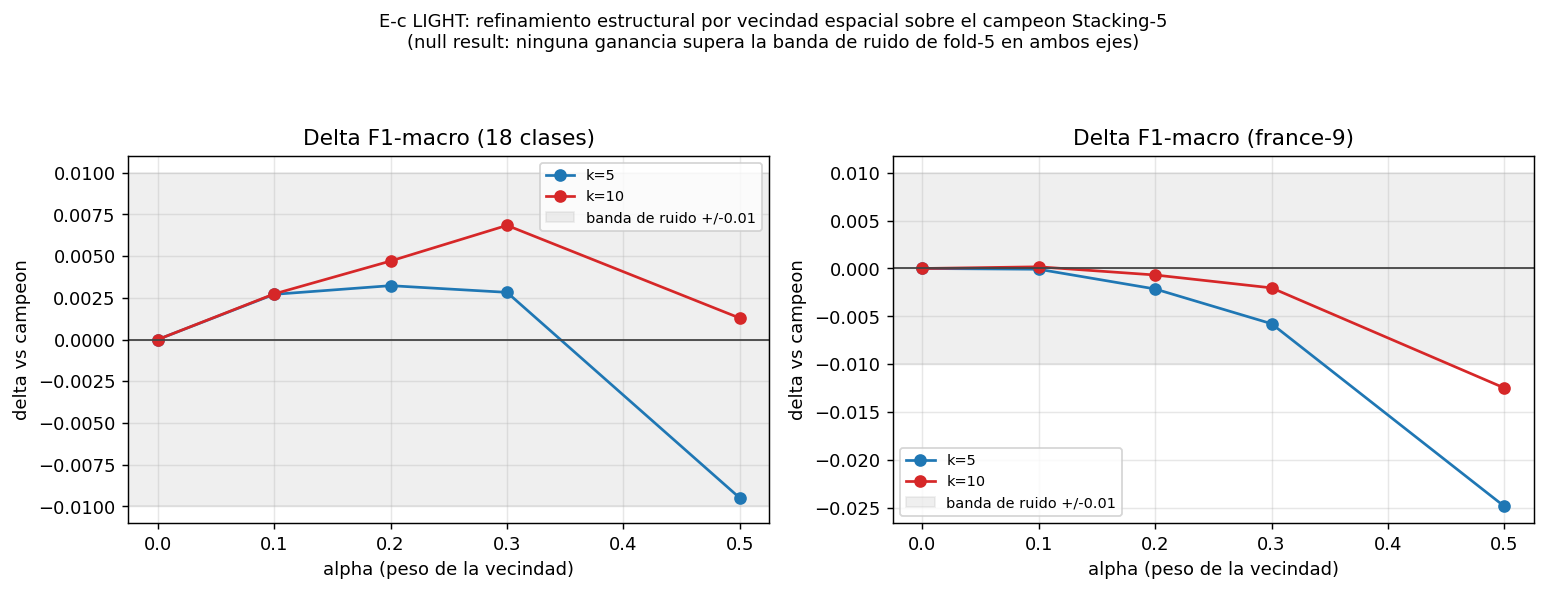

*Barrido del refinamiento por vecindad: el delta vs el campeon se queda dentro de la banda de ruido de fold-5 en ambos ejes; subir alpha solo degrada.*

In [4]:
# E-c LIGHT structural neighbourhood probe: load the materialised sweep and judge it
# against the champion. Artifact-only (JSON already on disk); no training here.
import json

_ec_path = Path(_PREFIX + 'reports/ensemble/metrics/ec_neighborhood_result.json')
if not _ec_path.is_file():
    display(Markdown(f'> _Pendiente: falta `{_ec_path}`._'))
else:
    _ec = json.loads(_ec_path.read_text(encoding='utf-8'))
    _champ = _ec['champion']
    sweep = pl.DataFrame(_ec['sweep']).select([
        'k', 'alpha',
        pl.col('f1_macro_18').round(4).alias('f1_macro_18c'),
        pl.col('f1_macro_france9').round(4).alias('f1_macro_fr9'),
        pl.col('accuracy').round(4),
        pl.col('delta_f1_macro_18').round(4).alias('delta_18c'),
        pl.col('delta_f1_macro_france9').round(4).alias('delta_fr9'),
    ])
    print('Campeon Stacking-5 (alpha=0): '
          f"F1-macro-18 {_champ['f1_macro_18']:.4f} | "
          f"france-9 {_champ['f1_macro_france9']:.4f} | "
          f"acc {_champ['accuracy']:.4f} sobre "
          f"{_champ['n_parcels']:,} parcelas".replace(',', '.'))
    _best = _ec['best_refined_on_both']
    print('Mejor punto que sube AMBOS ejes: '
          f"k={_best['k']} alpha={_best['alpha']} -> "
          f"delta-18 {_best['delta_f1_macro_18']:+.4f} | "
          f"delta-france9 {_best['delta_f1_macro_france9']:+.4f} "
          f"(umbral material {_ec['material_delta_threshold']:g}; "
          f"material en ambos: {_ec['material_both']})")
    print('Veredicto E-c LIGHT (mejora accionable sobre el campeon):', _ec['improves'])
    display(sweep)

    _fig = Path(_PREFIX + 'reports/ensemble/figures/ec_neighborhood_sweep.png')
    if _fig.is_file():
        display(Image(filename=str(_fig)))
        display(Markdown('*Barrido del refinamiento por vecindad: el delta vs el campeon se '
                         'queda dentro de la banda de ruido de fold-5 en ambos ejes; subir '
                         'alpha solo degrada.*'))

**Lectura del E-c LIGHT (el resultado nulo, contado con honestidad)**:

- El mejor punto que **sube los dos ejes** a la vez (`k=10`, `alpha=0.1`) deja el F1-macro-18 en **0,7513** (delta = **+0,0027**) y el france-9 en **0,9122** (delta = **+0,0002**). El segundo es esencialmente **ruido** (décimas de punto sobre ~16,6 mil parcelas) y el primero queda **por debajo del umbral material de 0,01** propio de la variabilidad de fold-5.
- En el eje de 18 clases existe un óptimo mayor (`k=10`, `alpha=0.3`, delta = **+0,0068**), pero a ese peso **ya degrada** el france-9 (delta = -0,0020): no hay un punto que mejore ambos de forma material.
- En cuanto el peso de la vecindad crece (`alpha>=0.5`) la mezcla **empeora claramente** -- el posterior del campeón ya es la mejor estimación local y promediar con vecinos solo lo emborrona.
- **Conclusión accionable**: el eje estructural por vecindad **no aporta** una mejora real sobre el campeón. Esto **confirma** lo que la rama tabular ya sugería (delta = 0,0 con clima y relieve): el **contexto espacial ya está absorbido por el embedding de AlphaEarth**, que codifica fenología y vecindad. Se reporta como **resultado nulo**, no como mejora -- la integridad del hallazgo vale más que un decimal de F1. La fuente es `reports/ensemble/metrics/ec_neighborhood_result.json` (`ml/ensemble/ec_neighborhood.py`), continuación natural de la serie incremental E-a / E-b.

## Selección del modelo final

Tabla única con el **mejor modelo individual** de la fase previa y **todos los ensambles**, ordenada por la métrica principal (F1-macro), con dos métricas adicionales (accuracy y costo de inferencia) y la **ganancia** frente al mejor individual.

In [5]:
# Unified comparative table (best individual + every ensemble). Built from the two
# results CSVs; annotates strategy and gain vs the best individual model.
BEST_INDIV_F1 = 0.6253  # best individual model of the previous phase (parcel level)

rows = [
    ('Mejor modelo individual', 'individual', BEST_INDIV_F1, None, None),
    ('Voting (homogenea, pixel)', 'homogenea', 0.6225, 0.8090, 42.49),
    ('Bagging (homogenea, parcela)', 'homogenea', 0.5864, 0.7816, 5.50),
    ('Blending (heterogenea, parcela)', 'heterogenea', 0.7414, 0.8618, 0.006),
    ('Stacking (heterogenea, parcela)', 'heterogenea', 0.7470, 0.8490, 0.042),
    ('Stacking + rama contrastiva (FINAL)', 'heterogenea+', 0.7486, 0.8495, 0.042),
]
comp = pl.DataFrame(
    rows, schema=['modelo', 'estrategia', 'f1_macro', 'accuracy', 'tiempo_inferencia_s'],
    orient='row',
).with_columns(
    (pl.col('f1_macro') - BEST_INDIV_F1).round(4).alias('ganancia_vs_individual')
).sort('f1_macro', descending=True)
display(comp)
print('Modelo final elegido:', comp.row(0, named=True)['modelo'])

modelo,estrategia,f1_macro,accuracy,tiempo_inferencia_s,ganancia_vs_individual
str,str,f64,f64,f64,f64
"""Stacking + rama contrastiva (F…","""heterogenea+""",0.7486,0.8495,0.042,0.1233
"""Stacking (heterogenea, parcela…","""heterogenea""",0.747,0.849,0.042,0.1217
"""Blending (heterogenea, parcela…","""heterogenea""",0.7414,0.8618,0.006,0.1161
"""Mejor modelo individual""","""individual""",0.6253,null,null,0.0
"""Voting (homogenea, pixel)""","""homogenea""",0.6225,0.809,42.49,-0.0028
"""Bagging (homogenea, parcela)""","""homogenea""",0.5864,0.7816,5.5,-0.0389


Modelo final elegido: Stacking + rama contrastiva (FINAL)


### Argumentación de la elección (trade-offs, no solo la métrica)

El **modelo final es el Stacking heterogéneo** (con la rama contrastiva como miembro extra), por estas razones:

1. **Máximo rendimiento**: F1-macro **0,749** sobre datos no vistos, **+12,3 puntos** sobre el mejor individual (0,625). Es el mejor de los siete ensambles.
2. **El meta-modelo aprovecha la complementariedad**: aprende a creerle a cada miembro según la clase — a los temporales en cultivos con fenología marcada, al tabular en los demás — algo que un promedio fijo no puede hacer.
3. **Costo de inferencia despreciable**: 0,042 s por inferencia una vez calculadas las probabilidades base. El entrenamiento del ensamble es el ajuste del meta-modelo (segundos), porque reutiliza las salidas ya calculadas de los modelos base.
4. **Alternativa documentada**: el **Blending** queda muy cerca (0,741) con mejor accuracy (0,862) y menor latencia (0,006 s). Es la opción si el negocio prioriza accuracy global y latencia sobre F1-macro. Se elige Stacking porque bajo el fuerte desbalance de clases el **F1-macro** es la métrica alineada con el objetivo (clasificar bien también los cultivos raros), no la accuracy.

> **Alineación con el negocio**: el producto debe identificar correctamente cultivos minoritarios (de mayor valor agronómico y económico), no solo el prado dominante. El F1-macro castiga fallar en las clases raras; por eso guía la selección.

## Gráficos del modelo final con interpretación

Ocho figuras del modelo final, cada una con su lectura. Todas se calculan sobre el **fold reservado** (datos no vistos).

### 1. Matriz de confusión

Muestra, para cada cultivo real (filas), cómo se reparten las predicciones (columnas). La diagonal son los aciertos.

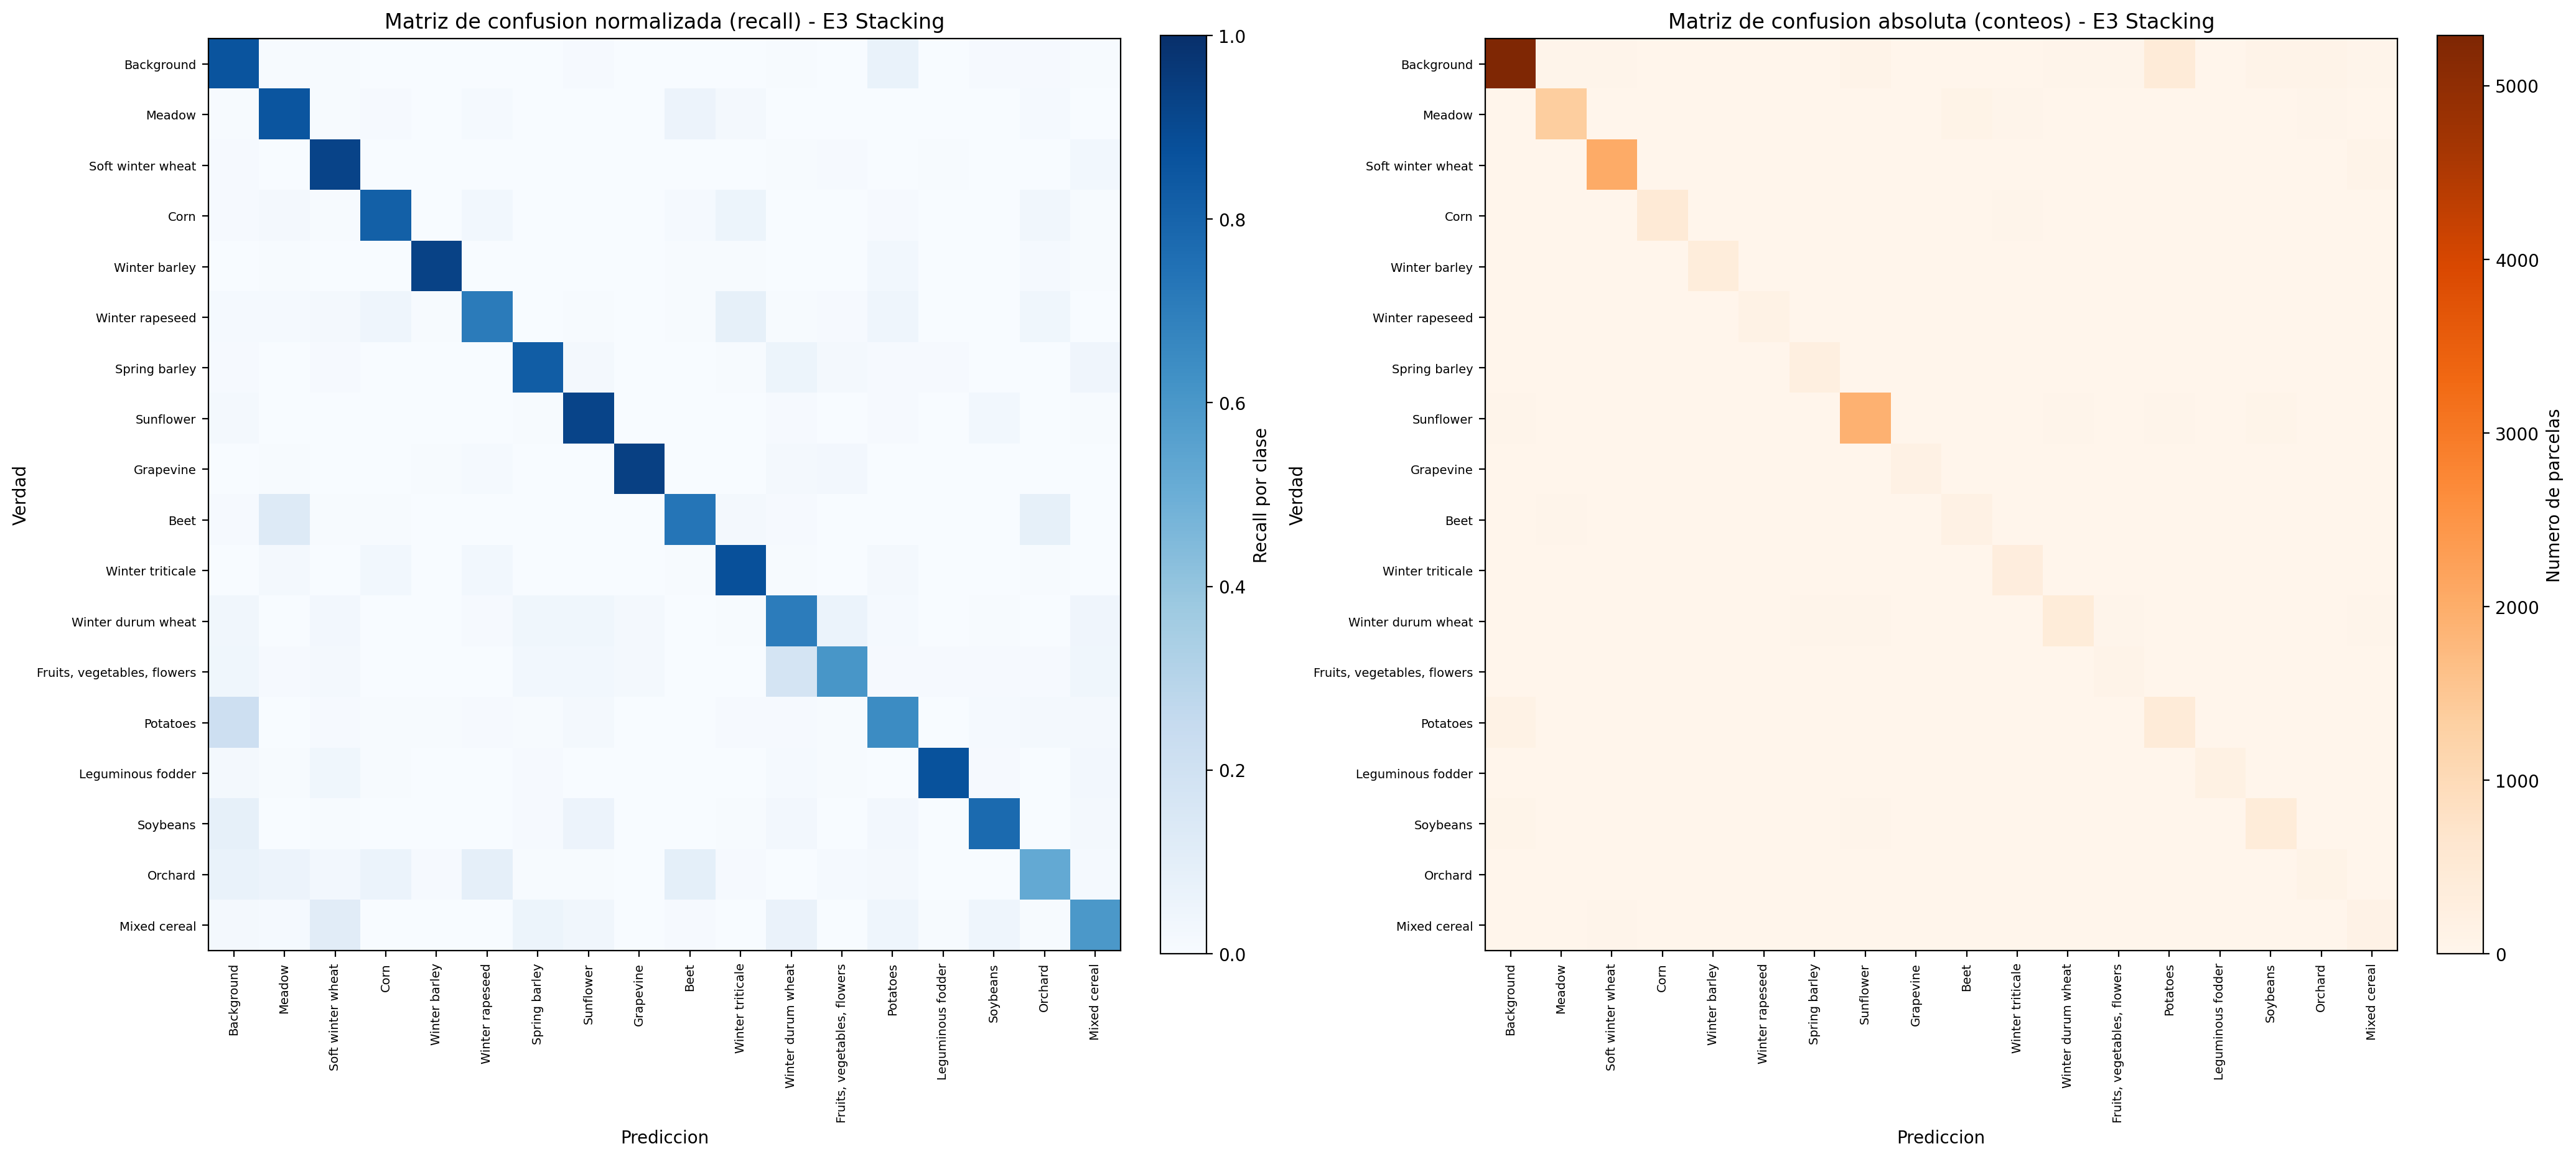

*Matriz de confusión del modelo final sobre el fold reservado.*

In [6]:
show_fig('confusion_stacking.png',
         'Matriz de confusión del modelo final sobre el fold reservado.')

**Interpretación**: la diagonal concentra la masa — el modelo acierta la mayoría de las parcelas. Los errores no son aleatorios: se agrupan entre **cultivos de ciclo parecido** (cereales de invierno entre sí, por ejemplo), exactamente donde la firma temporal es ambigua. Las pocas confusiones grandes caen en clases minoritarias con poco soporte, que arrastran el F1-macro.

### 2. Curva ROC (uno-contra-resto)

Para cada clase, la capacidad de separar ese cultivo del resto a distintos umbrales. El área bajo la curva (AUC) resume esa capacidad.

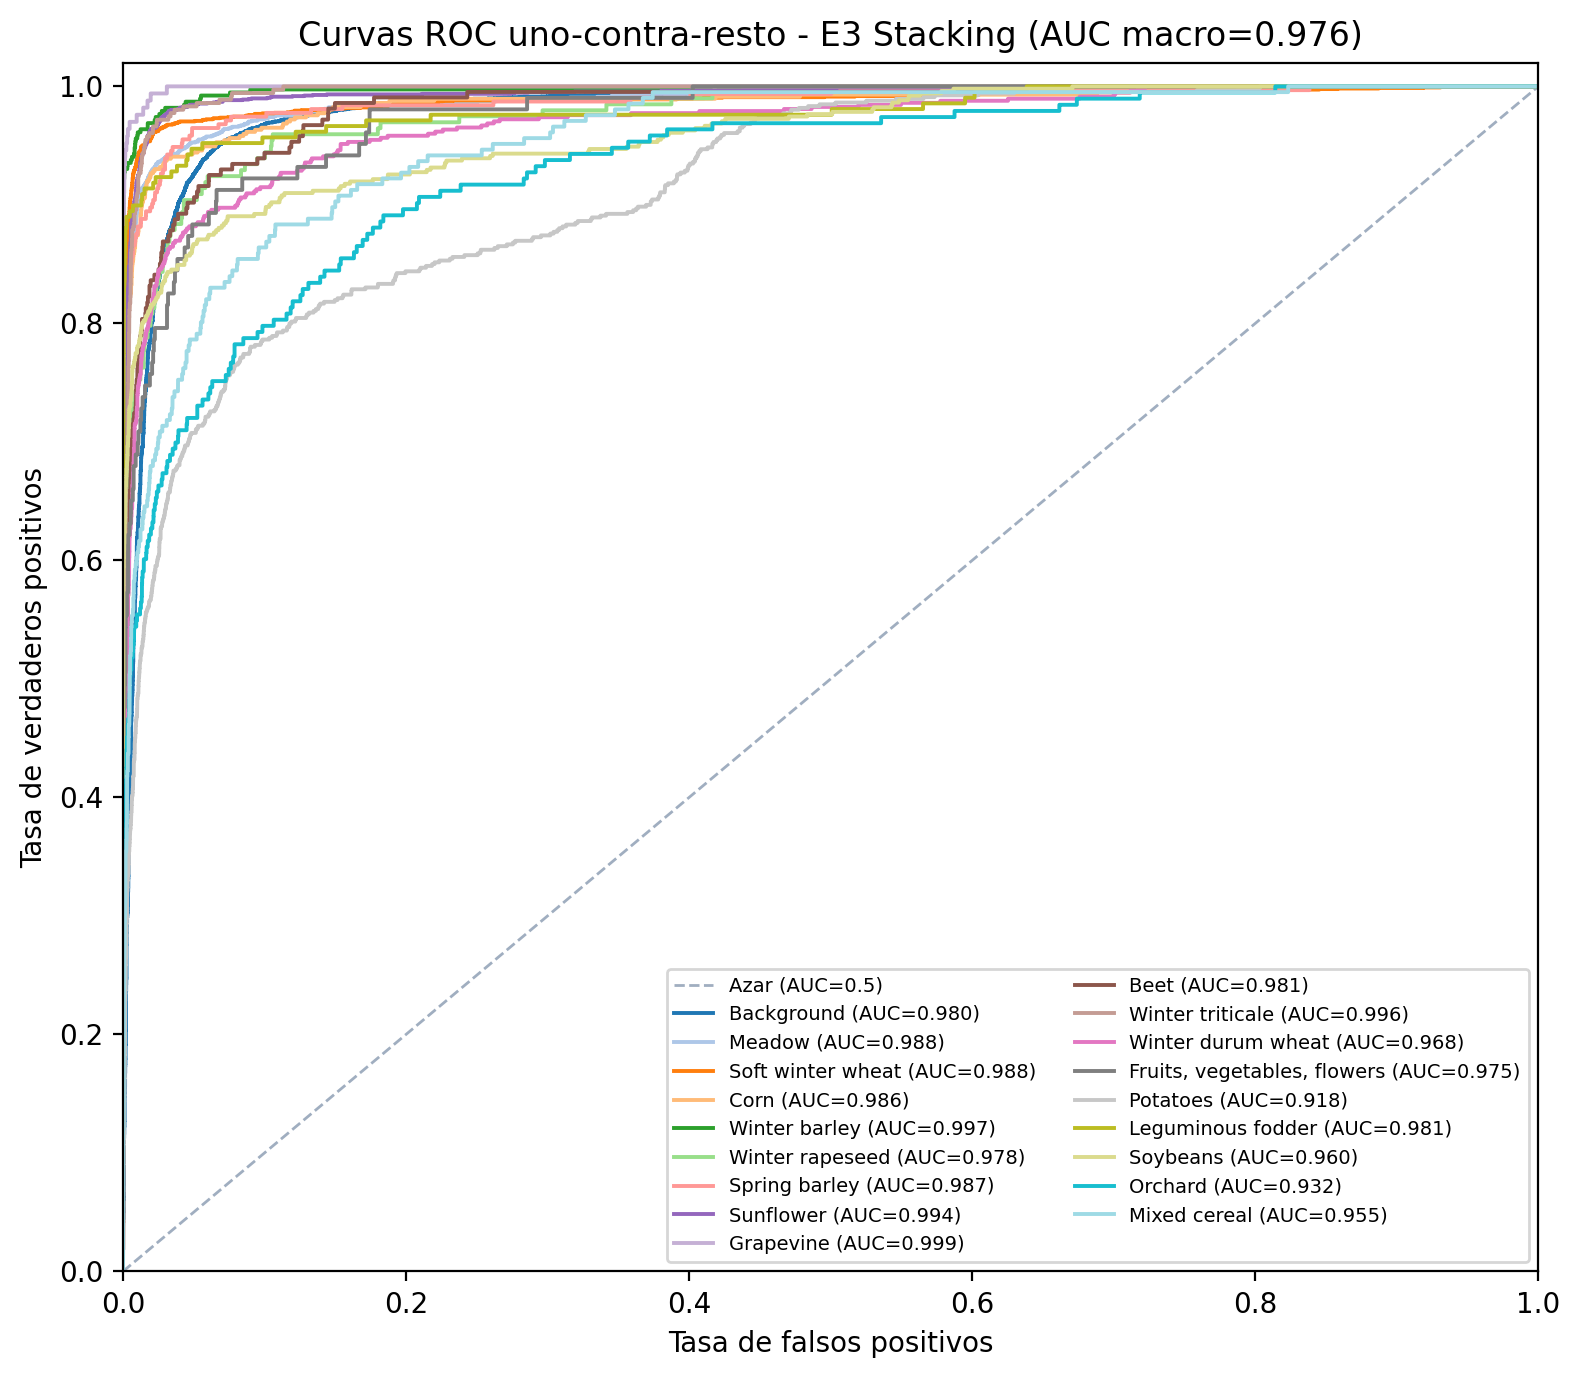

*ROC uno-contra-resto por clase y macro-promedio.*

In [7]:
show_fig('roc_ovr_stacking.png',
         'ROC uno-contra-resto por clase y macro-promedio.')

**Interpretación**: el AUC macro es **0,976**, muy alto. Pero hay que leerlo con cuidado: el AUC se deja engañar por los muchos negativos fáciles bajo desbalance, por lo que la cifra realista del poder del modelo es la precisión-recall que sigue, no este 0,976.

### 3. Curva de precisión-recall

La figura **más informativa bajo desbalance**: ignora los negativos fáciles y mide la calidad real por clase. El área (AP, average precision) la resume.

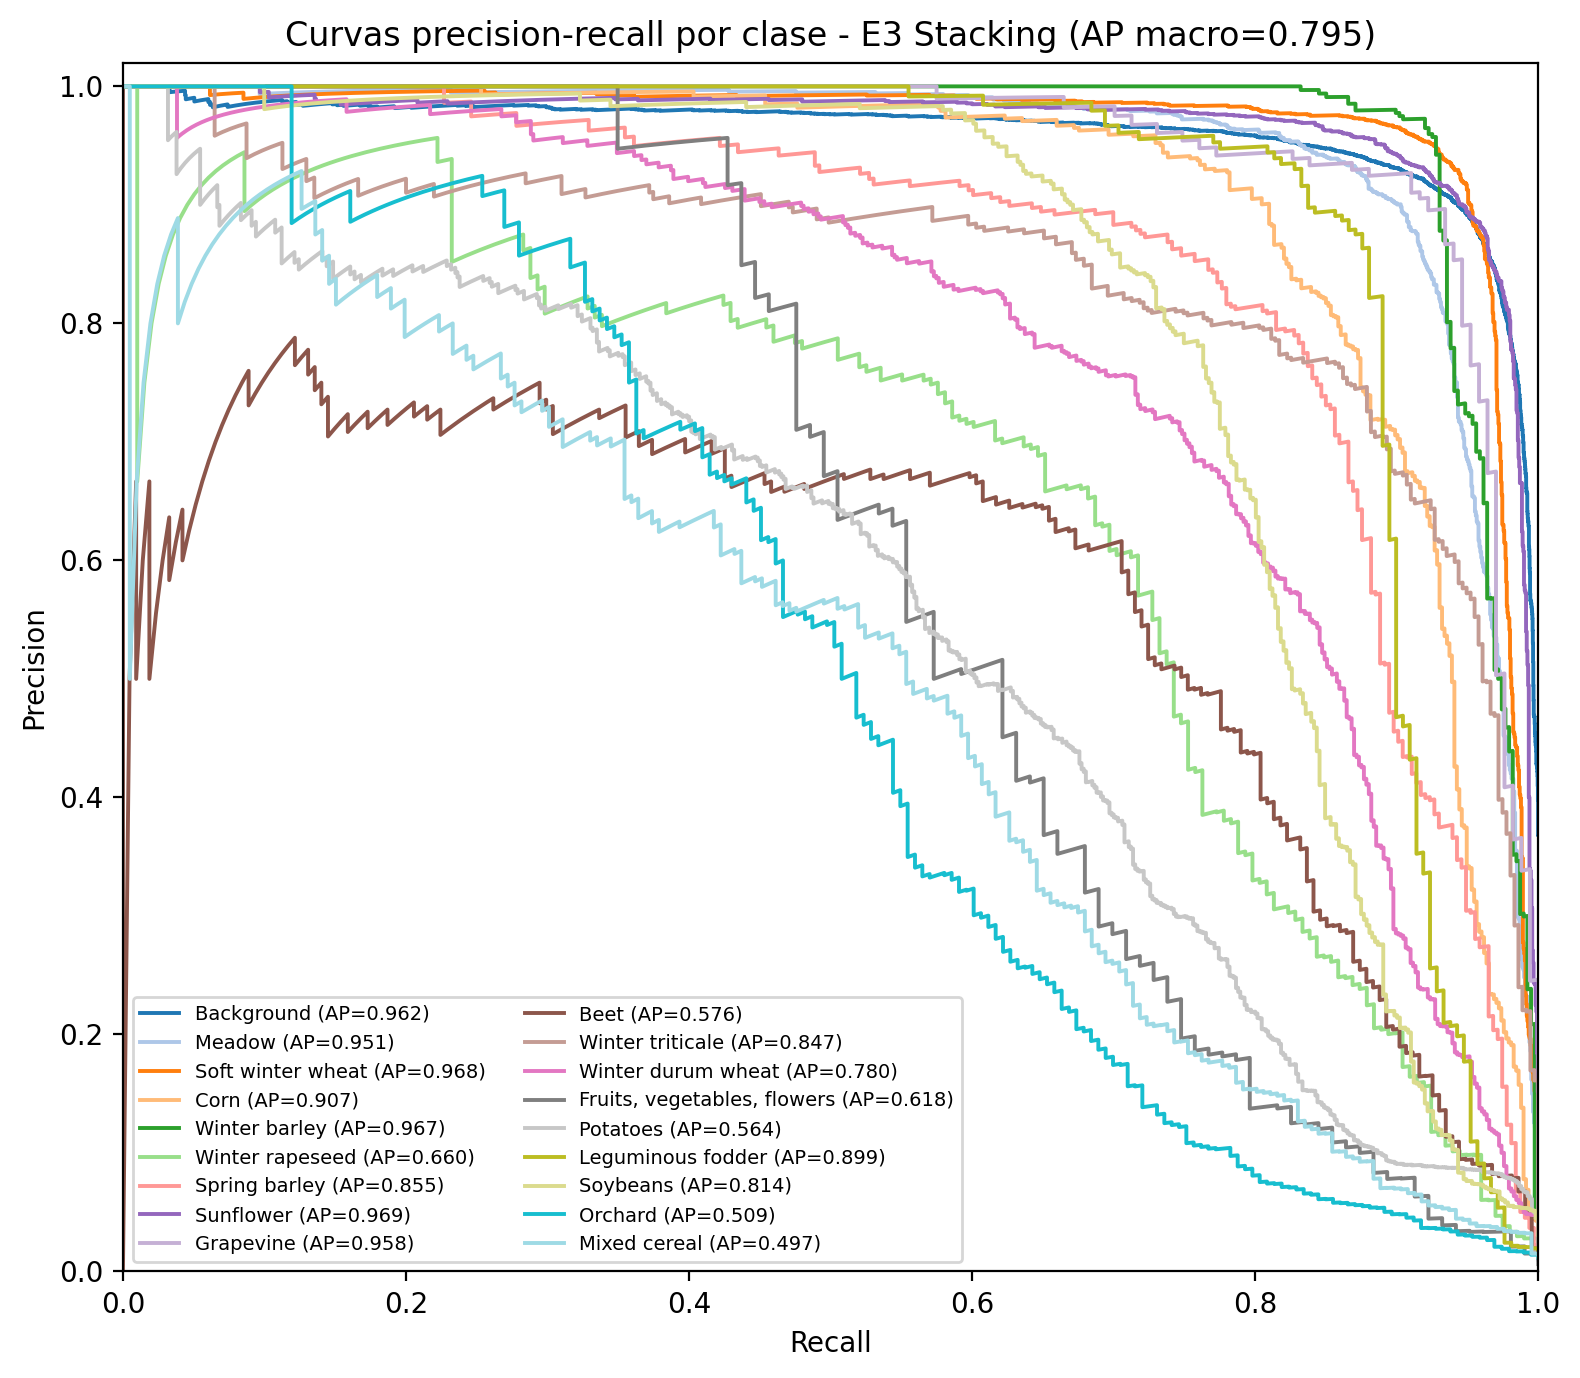

*Precisión-recall por clase; el AP macro es la cifra realista.*

In [8]:
show_fig('pr_stacking.png',
         'Precisión-recall por clase; el AP macro es la cifra realista.')

**Interpretación**: el **AP macro es 0,795**, más bajo que el AUC 0,976 — y esa es la cifra honesta. Se ven tres grupos: cultivos fuertes (>0,90: girasol, trigo de invierno, vid, prado, maíz) con firma marcada y muchas muestras; intermedios (0,78-0,90); y débiles (<0,66: colza, frutas/verduras, remolacha, patata, huerto, cereal mixto) con pocas muestras o fenología ambigua. El patrón es nítido: el modelo brilla donde hay señal clara y datos, y sufre en las clases raras.

### 4. Análisis de residuos espaciales

Dónde se equivoca el modelo sobre el mapa: si los errores se concentran en una zona geográfica o se reparten.

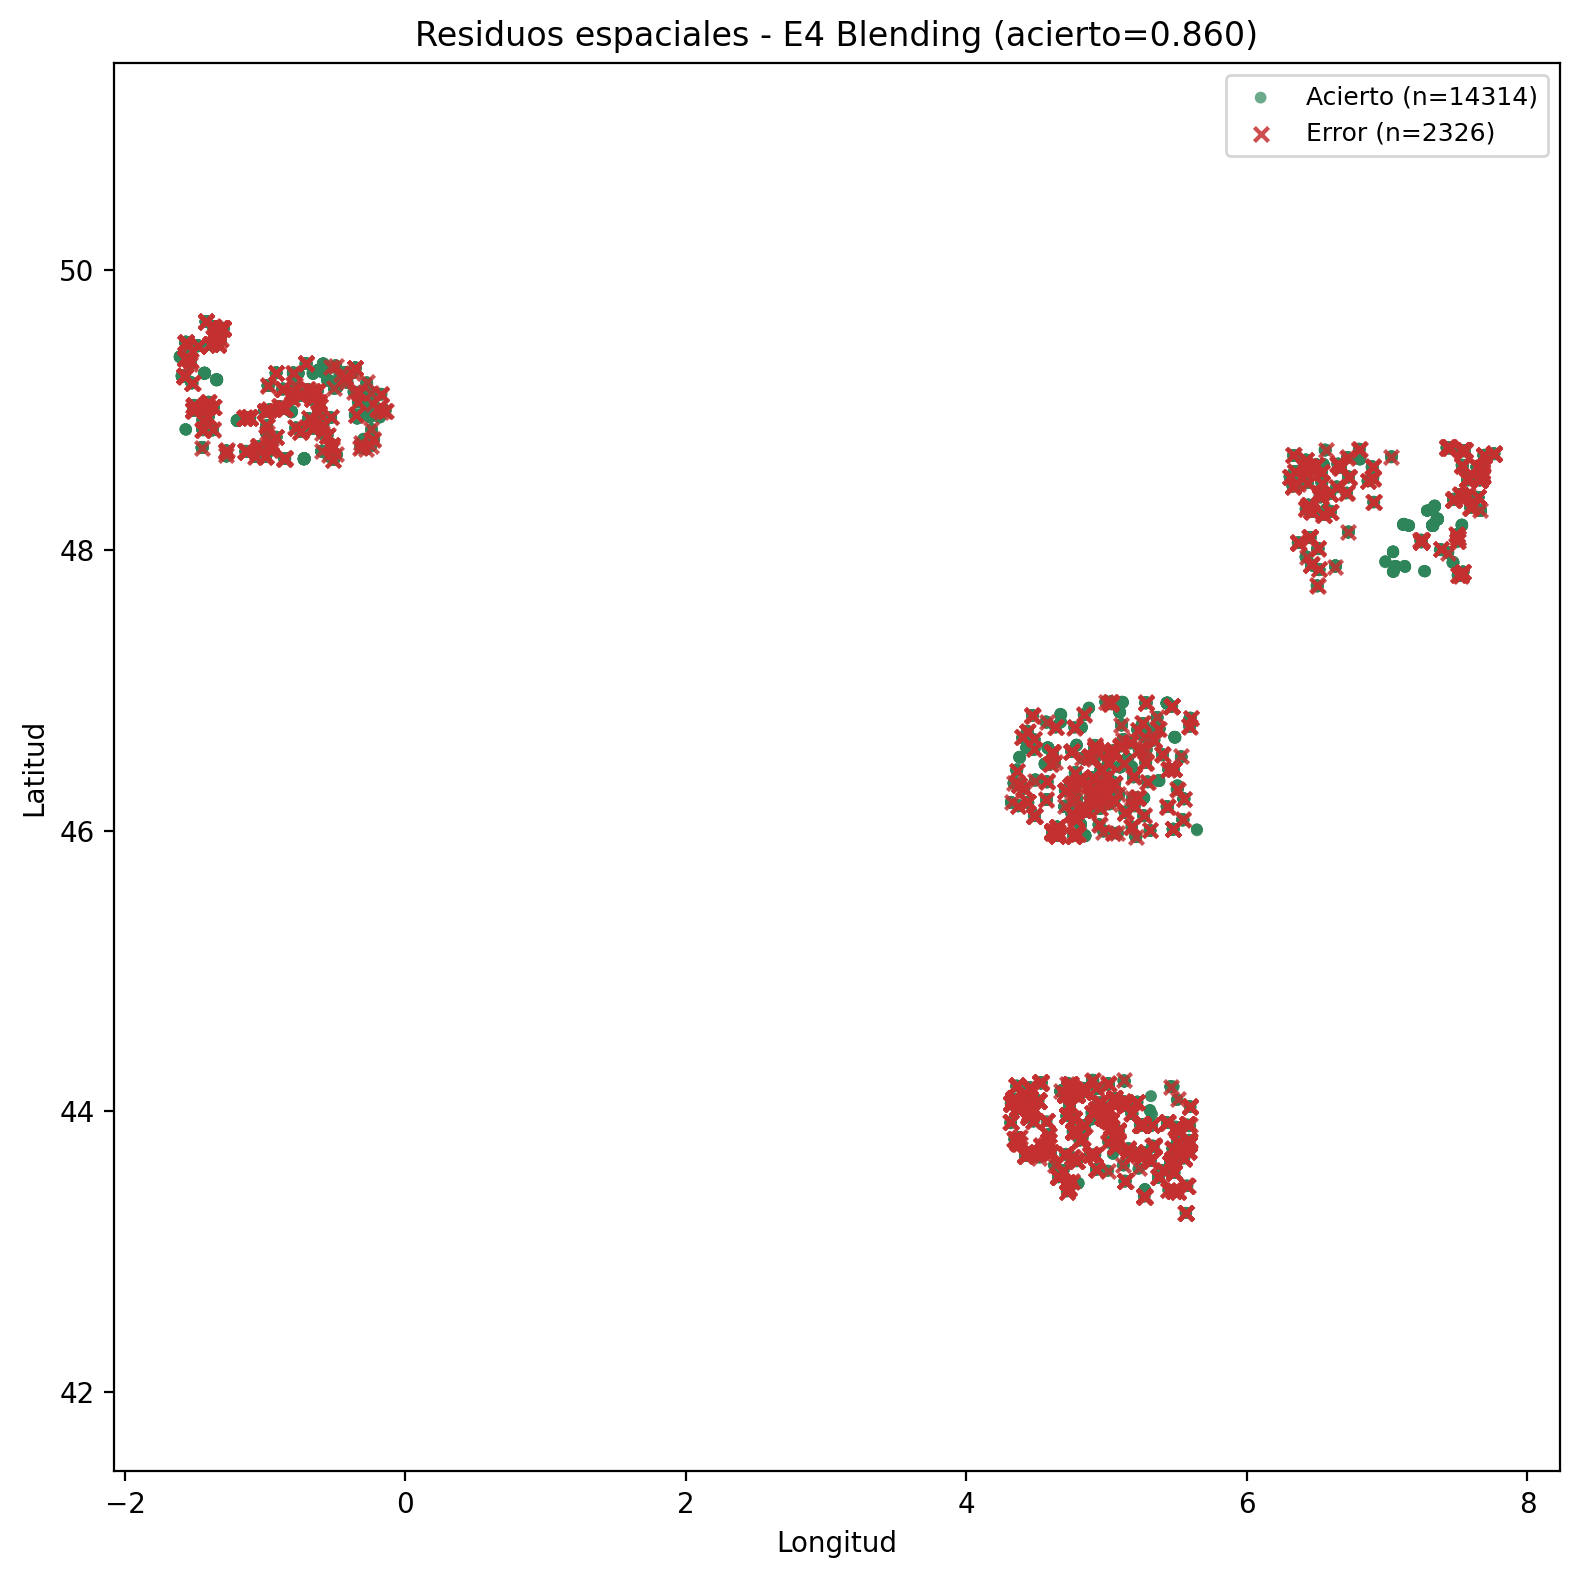

*Distribución espacial de aciertos y errores sobre el fold reservado.*

In [9]:
show_fig('spatial_residuals_blending.png',
         'Distribución espacial de aciertos y errores sobre el fold reservado.')

**Interpretación**: los errores **no se concentran geográficamente** — se reparten por el territorio. Esto descarta que falte cubrir una región concreta; el error vive en clases difíciles, no en zonas. Una consecuencia práctica: recolectar más datos de una sola zona no arreglaría el problema; atacar las clases raras, sí.

### 5. F1 por clase del modelo final

El rendimiento desglosado por cultivo, que explica de dónde sale el F1-macro global.

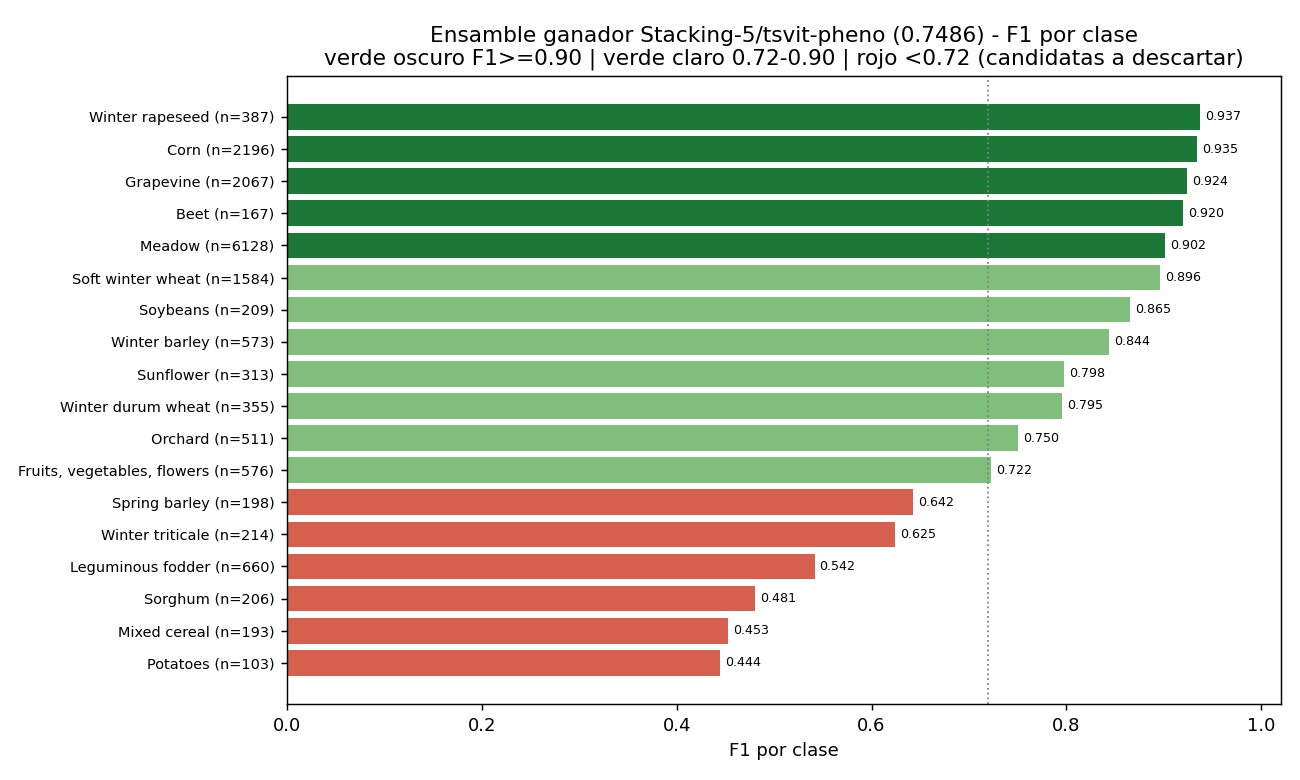

*F1 por clase del modelo final (ordenado).*

In [10]:
show_fig('us043_farslip/winner_per_class_f1.png',
         'F1 por clase del modelo final (ordenado).')

**Interpretación**: hay un gradiente claro de cultivos bien resueltos (colza, maíz, vid, remolacha, prado, con F1 > 0,90) a cultivos difíciles (patata, cereal mixto, sorgo, con F1 < 0,50). Las clases débiles comparten dos rasgos: **poco soporte** y **fenología ambigua** (se confunden con parientes cercanos). Son el objetivo natural de mejora.

### 6. Curva de cardinalidad: cuántos cultivos resuelve bien

Responde a una pregunta de negocio: si nos quedamos con los K cultivos mejor resueltos, qué F1 promedio se obtiene y qué fracción de parcelas se cubre.

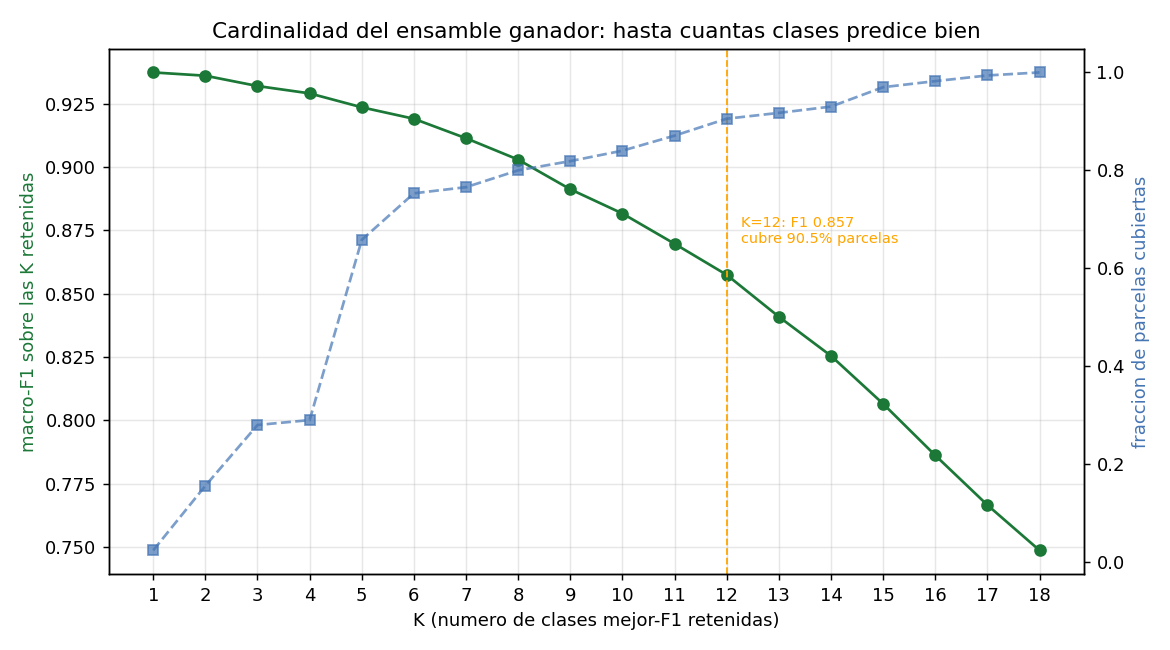

*F1-macro promedio reteniendo los K cultivos mejor resueltos.*

In [11]:
show_fig('us043_farslip/winner_cardinality_curve.png',
         'F1-macro promedio reteniendo los K cultivos mejor resueltos.')

**Interpretación**: el modelo resuelve **muy bien ~8 cultivos** (F1-macro 0,90, cubriendo el 80 % de las parcelas) y **bien hasta ~12** (F1-macro 0,86, 90 % de las parcelas). El "codo" indica que el grueso del valor de negocio se captura con los 12 cultivos principales; las últimas seis clases raras son las que bajan el promedio global a 0,749.

### 7. Descarte honesto de clases

Qué pasaría con el F1-macro si se descartaran las clases más débiles — medido sin hacer trampa: el ranking de qué clase descartar se decide sobre las probabilidades out-of-fold y la métrica se mide sobre el fold reservado restringido a las clases que se conservan.

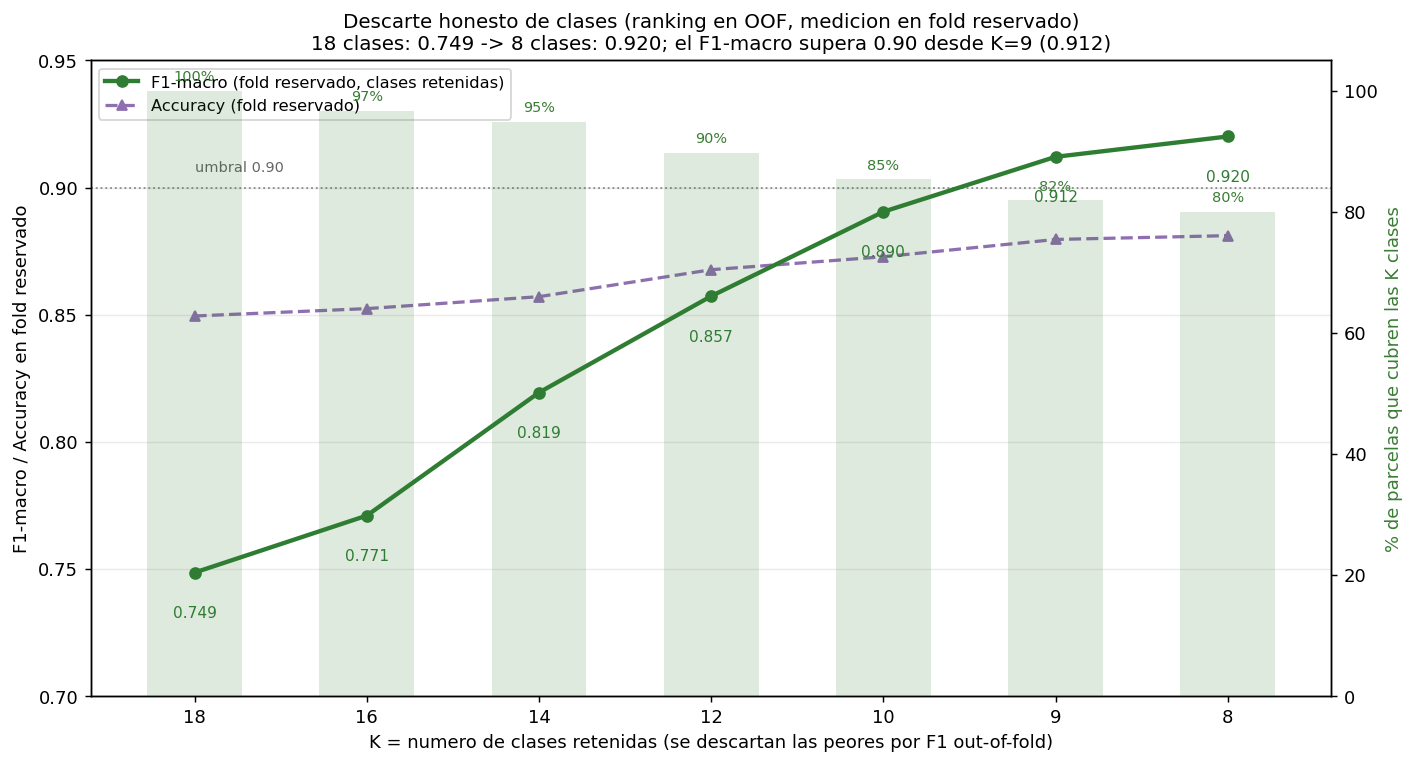

*F1-macro al conservar las K clases mejor rankeadas (sin cherry-picking).*

In [12]:
show_fig('us043_farslip/honest_class_dropout.png',
         'F1-macro al conservar las K clases mejor rankeadas (sin cherry-picking).')

**Interpretación**: conservar 12 clases (descartando las 6 más débiles) subiría el F1-macro a **0,86** cubriendo aún **el 90 %** de las parcelas reales, y el F1-macro **supera 0,90 a partir de las 9 clases mejor resueltas** (0,912, conservando el 82 % de las parcelas). Es un trade-off de producto útil: si el negocio tolera no clasificar una fracción de las parcelas raras, la calidad sobre el resto sube de forma marcada. El descarte se decide sobre datos de entrenamiento, no sobre el fold de prueba, para que la mejora sea creíble y no un artefacto de selección.

### 8. El modelo final en acción (parcela a parcela)

Sobre escenas reales del fold reservado con muchos cultivos distintos: la imagen de satélite, la verdad de campo y la predicción del modelo final, lado a lado. Debajo, la **descripción fenológica** (derivada de la curva NDVI real de cada parcela) que **apoya cada predicción** — la misma señal que explota la rama contrastiva.

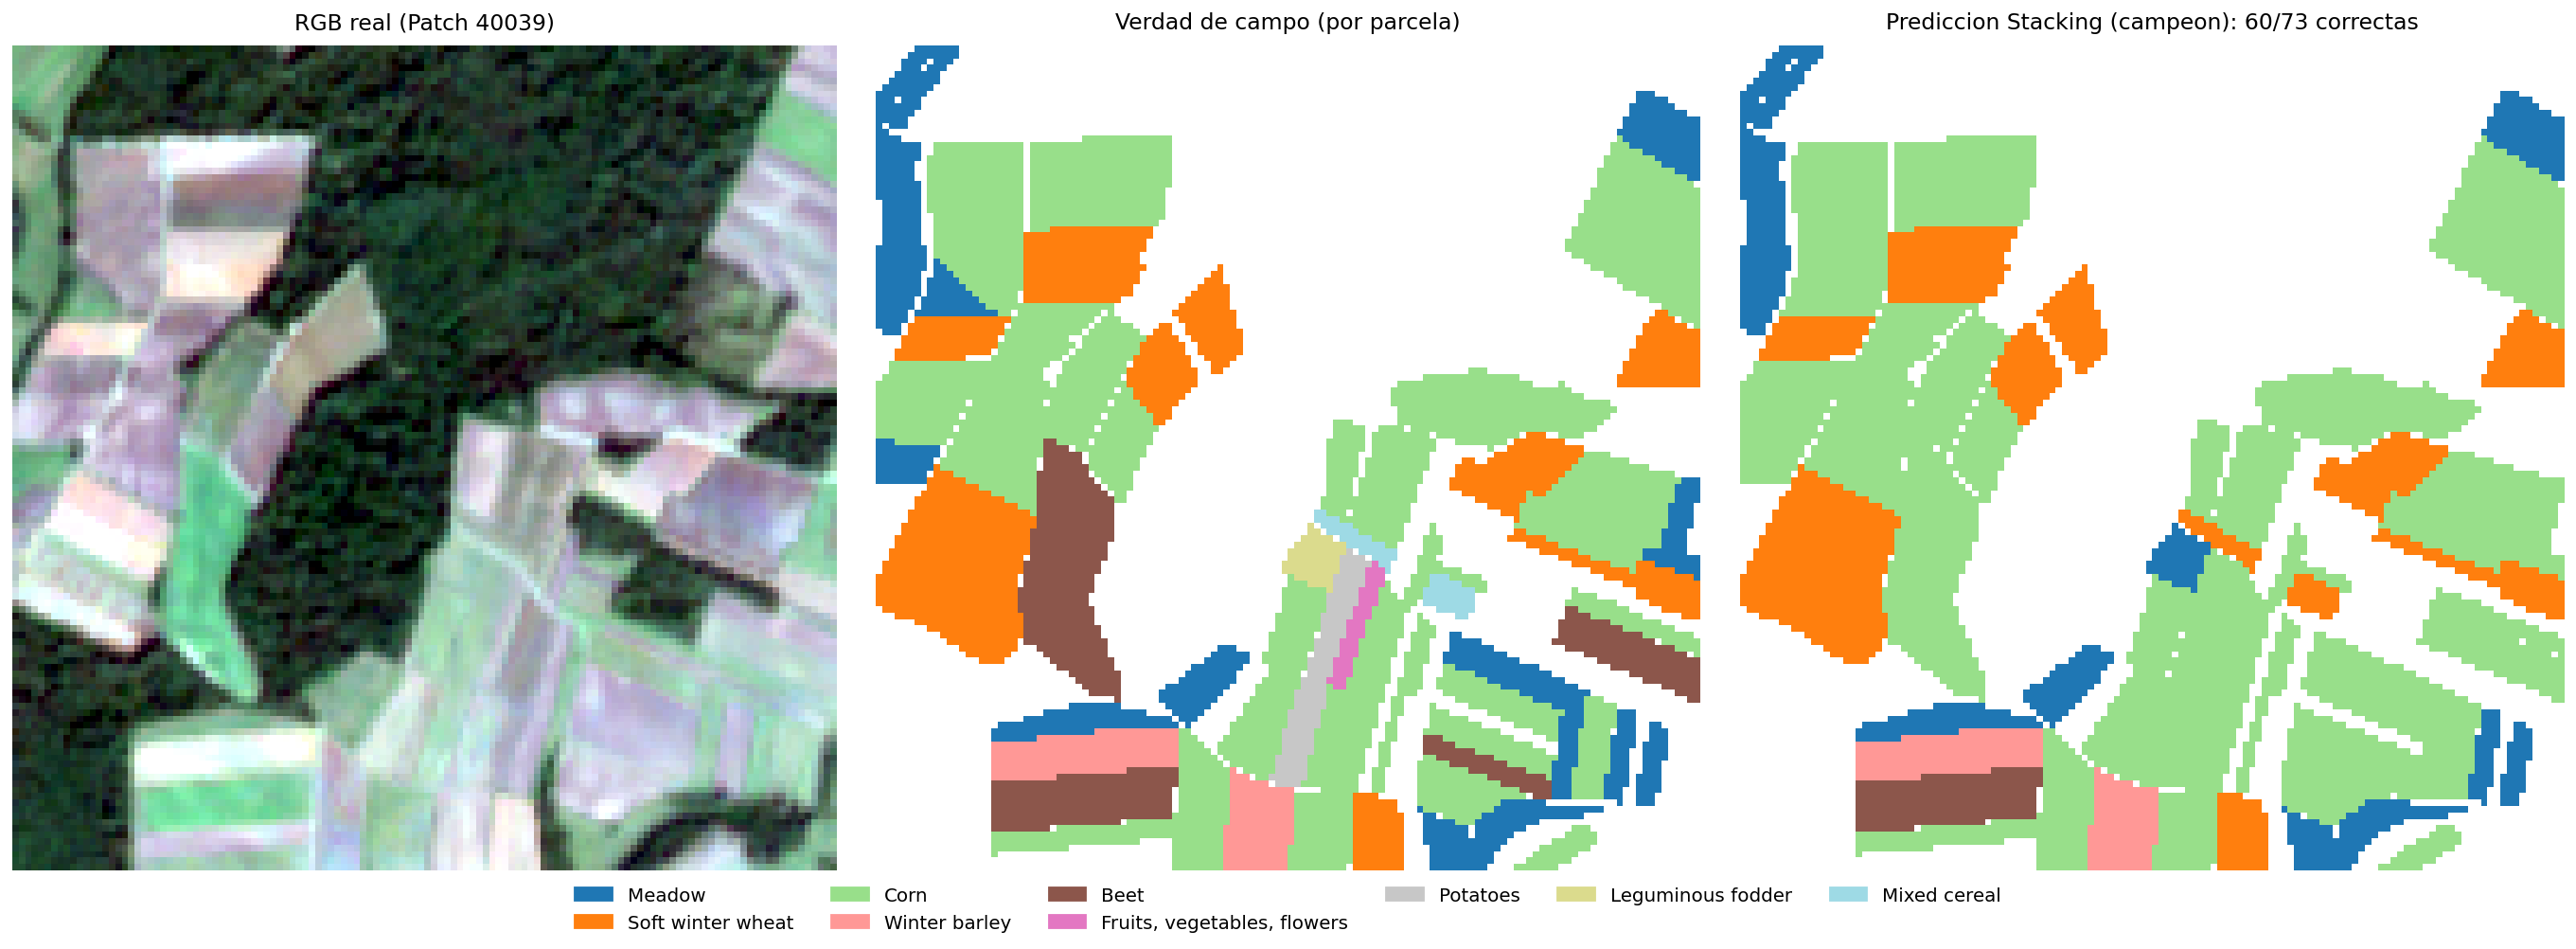

*Escena 40039: izq RGB real | centro verdad de campo | der predicción del modelo final.*

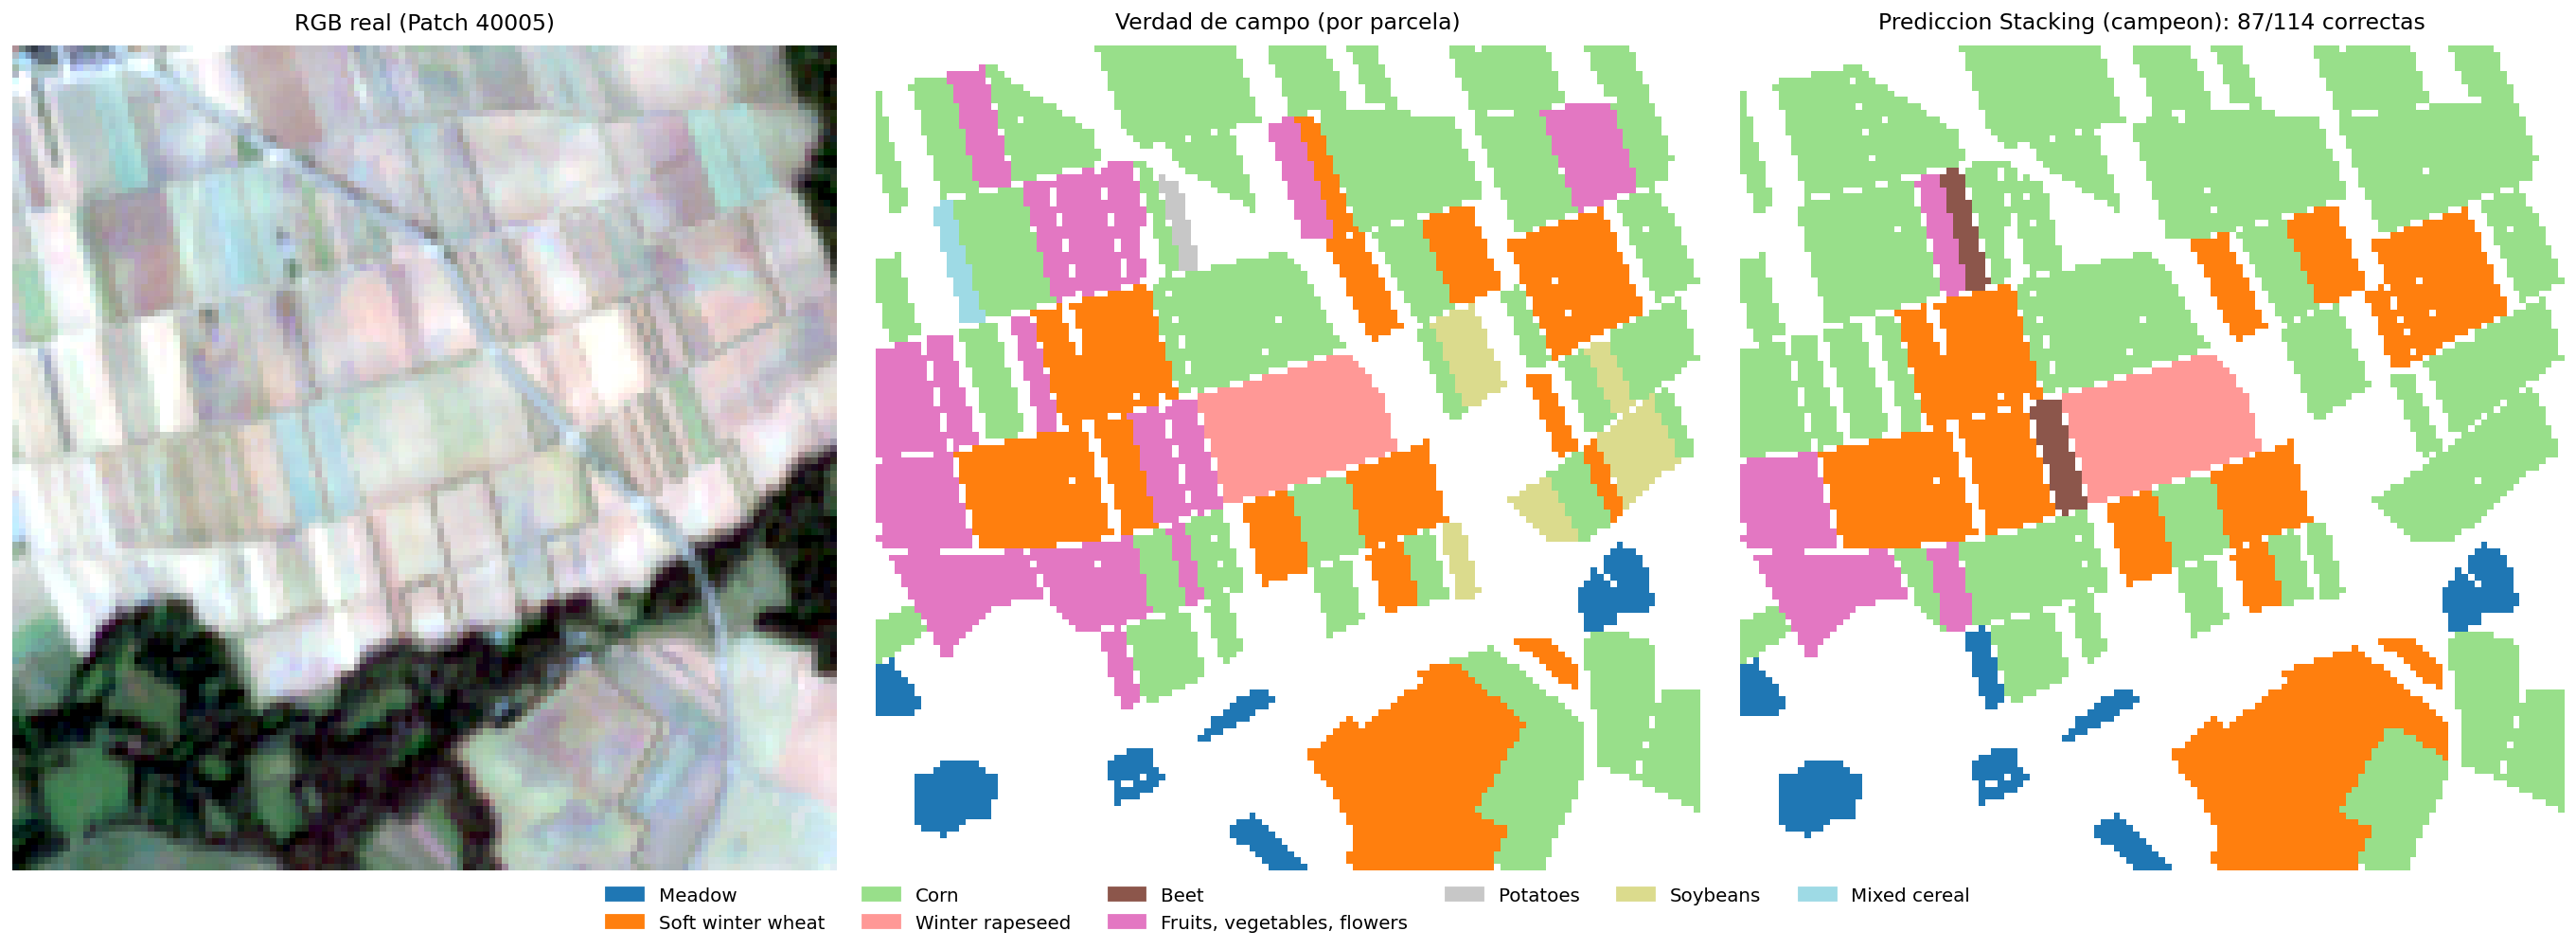

*Escena 40005: izq RGB real | centro verdad de campo | der predicción del modelo final.*

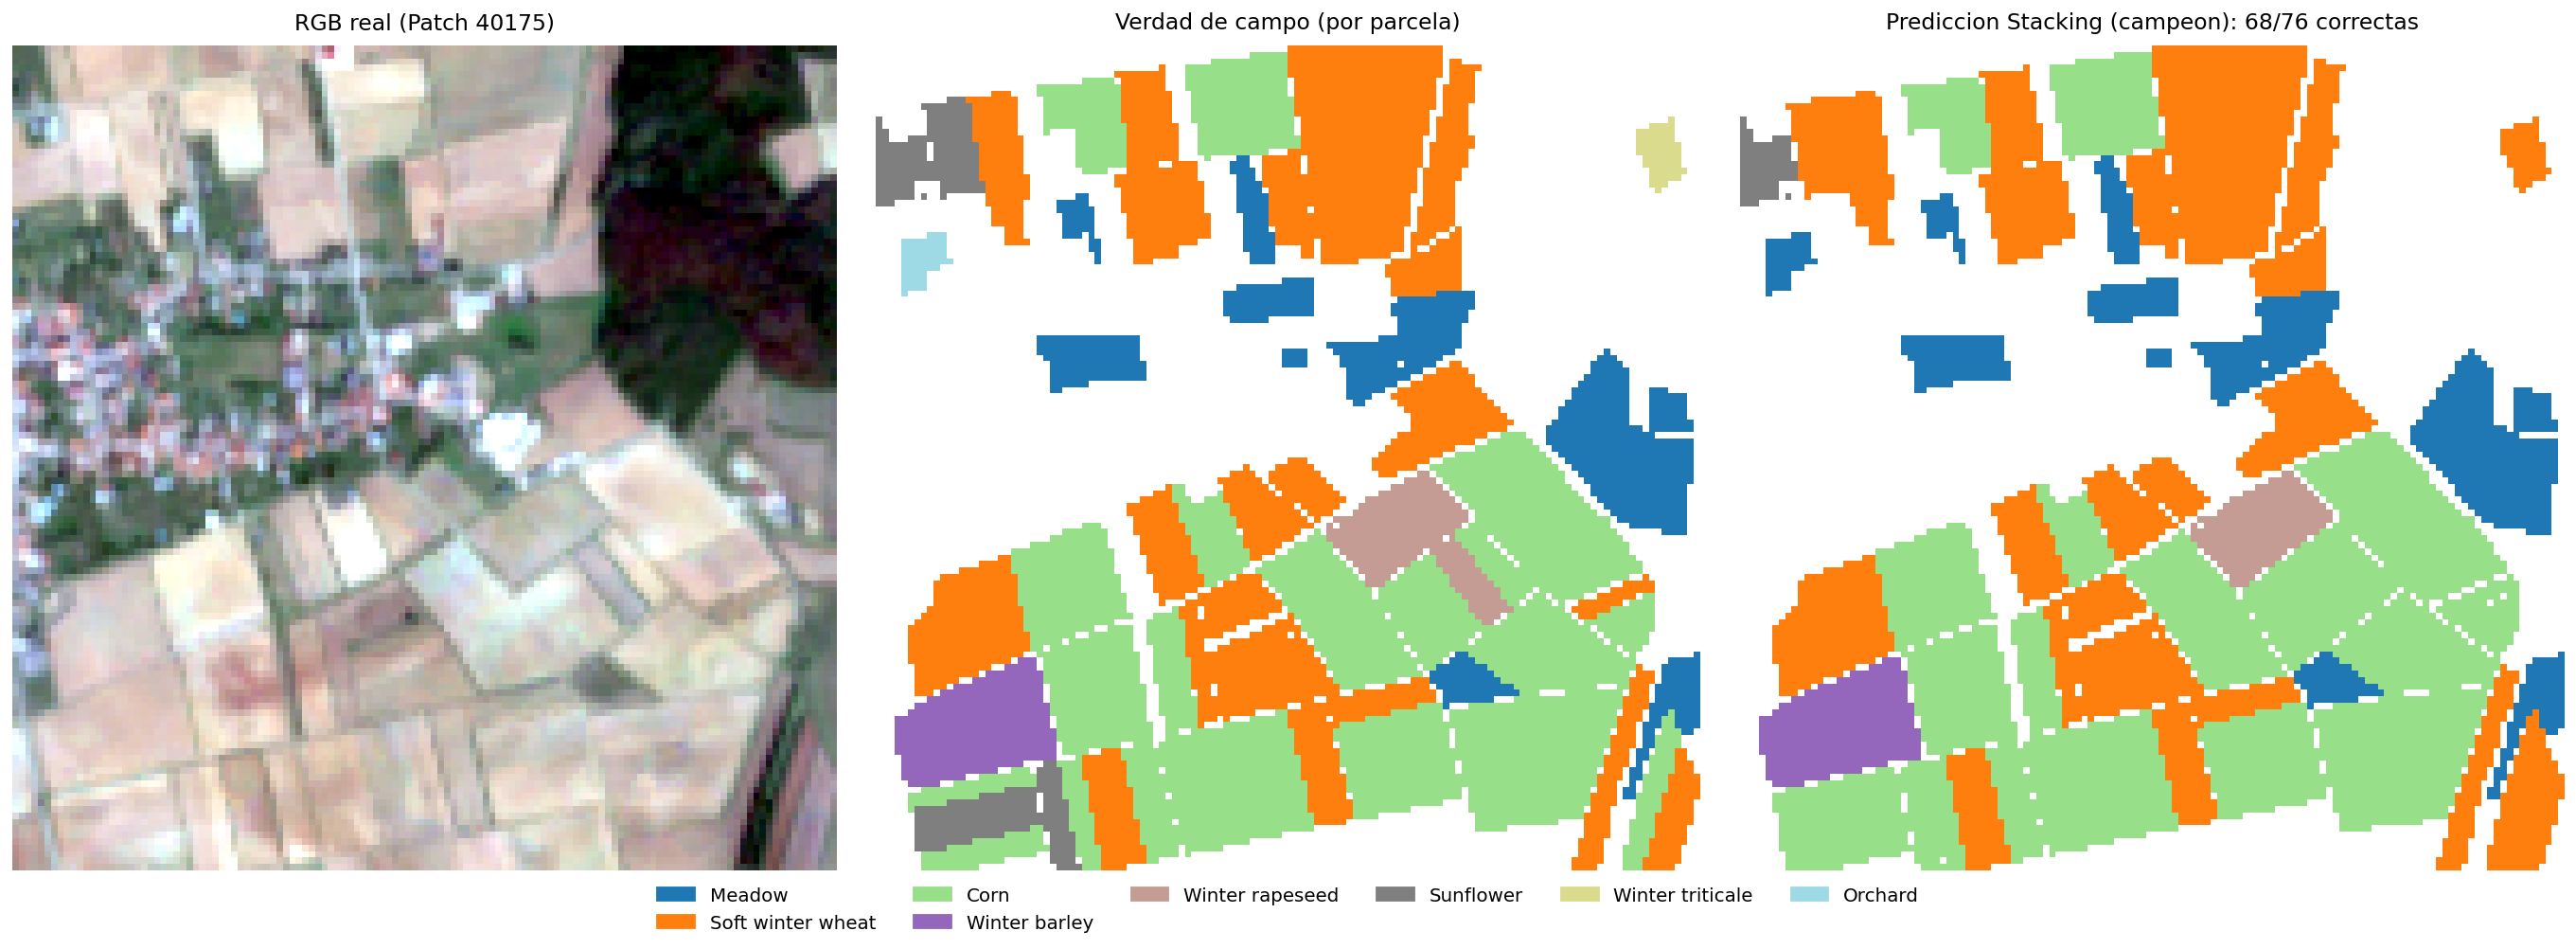

*Escena 40175: izq RGB real | centro verdad de campo | der predicción del modelo final.*

**Escena 40039** — fenología (curva NDVI por parcela) que apoya la predicción:

- **Corn** (real: Beet, error, pico NDVI 0.895): pico de vigor alto (NDVI 0.89) tardío; dinámica estacional marcada (amplitud 0.85)
- **Corn** (real: Corn, acierto, pico NDVI 0.861): pico de vigor alto (NDVI 0.86) tardío; dinámica estacional marcada (amplitud 0.82)
- **Corn** (real: Corn, acierto, pico NDVI 0.872): pico de vigor alto (NDVI 0.87) tardío; dinámica estacional marcada (amplitud 0.81)
- **Soft winter wheat** (real: Soft winter wheat, acierto, pico NDVI 0.842): pico de vigor alto (NDVI 0.84) a media temporada; dinámica estacional marcada (amplitud 0.79)
- **Beet** (real: Beet, acierto, pico NDVI 0.883): pico de vigor alto (NDVI 0.88) tardío; dinámica estacional marcada (amplitud 0.83)
- **Corn** (real: Corn, acierto, pico NDVI 0.893): pico de vigor alto (NDVI 0.89) tardío; dinámica estacional marcada (amplitud 0.86)

**Escena 40005** — fenología (curva NDVI por parcela) que apoya la predicción:

- **Soft winter wheat** (real: Soft winter wheat, acierto, pico NDVI 0.906): pico de vigor alto (NDVI 0.91) a media temporada; dinámica estacional marcada (amplitud 0.88)
- **Corn** (real: Corn, acierto, pico NDVI 0.855): pico de vigor alto (NDVI 0.85) a media temporada; dinámica estacional marcada (amplitud 0.82)
- **Corn** (real: Corn, acierto, pico NDVI 0.847): pico de vigor alto (NDVI 0.85) tardío; dinámica estacional marcada (amplitud 0.81)
- **Corn** (real: Corn, acierto, pico NDVI 0.859): pico de vigor alto (NDVI 0.86) tardío; dinámica estacional marcada (amplitud 0.83)
- **Soft winter wheat** (real: Soft winter wheat, acierto, pico NDVI 0.773): pico de vigor alto (NDVI 0.77) a media temporada; dinámica estacional marcada (amplitud 0.75)
- **Corn** (real: Corn, acierto, pico NDVI 0.816): pico de vigor alto (NDVI 0.82) tardío; dinámica estacional marcada (amplitud 0.80)

**Escena 40175** — fenología (curva NDVI por parcela) que apoya la predicción:

- **Meadow** (real: Meadow, acierto, pico NDVI 0.703): pico de vigor alto (NDVI 0.70) temprano; dinámica estacional marcada (amplitud 0.63)
- **Winter barley** (real: Winter barley, acierto, pico NDVI 0.827): pico de vigor alto (NDVI 0.83) a media temporada; dinámica estacional marcada (amplitud 0.79)
- **Corn** (real: Corn, acierto, pico NDVI 0.878): pico de vigor alto (NDVI 0.88) tardío; dinámica estacional marcada (amplitud 0.84)
- **Corn** (real: Corn, acierto, pico NDVI 0.786): pico de vigor alto (NDVI 0.79) tardío; dinámica estacional marcada (amplitud 0.76)
- **Soft winter wheat** (real: Soft winter wheat, acierto, pico NDVI 0.921): pico de vigor alto (NDVI 0.92) a media temporada; dinámica estacional marcada (amplitud 0.87)
- **Corn** (real: Corn, acierto, pico NDVI 0.837): pico de vigor alto (NDVI 0.84) tardío; dinámica estacional marcada (amplitud 0.79)

In [13]:
# Three diverse scenes (8-9 crops each) of the final model in action, with the
# phenology that supports each prediction shown as text below (never on the image).
for _pid in ['40039', '40005', '40175']:
    show_fig(f'inference/inference_stacking--campeon_{_pid}.png',
             f'Escena {_pid}: izq RGB real | centro verdad de campo | der predicción del modelo final.')
show_phenology('campeon')

**Interpretación**: la mayoría de las parcelas conservan su color entre el panel de verdad y el de predicción — el modelo reproduce el **mosaico agrícola completo**, no solo la clase dominante. La fenología de cada parcela conecta la decisión con una señal agronómica: las parcelas bien resueltas tienen una curva NDVI con pico claro y dinámica marcada; las que el modelo confunde suelen compartir fenología con un vecino (p. ej. cereales de invierno entre sí).

## Los ensambles que NO ganaron, también en acción

No solo el campeón merece verse trabajando. Aquí las mismas escenas para **dos ensambles que no ganaron**, con su **predicción real** (no un consenso aproximado), para ver *dónde* fallan distinto al ganador:

- **Blending-3 (subcampeón, 0,744)**: la mezcla convexa de los tres miembros base. Muy cerca del campeón en F1 y con mejor accuracy, pero sin árbitro por clase.
- **Stacking-5/fullm (0,648)**: el stacking que usa como base el *mejor segmentador individual* y le suma la rama contrastiva. Pese a partir del miembro más fuerte, apila peor — la evidencia visual de que la complementariedad manda sobre la fuerza individual.

En cada caso se muestra la predicción parcela a parcela y, debajo, la **descripción fenológica que apoya esa predicción** (curva NDVI por parcela), nunca sobre la imagen.

### Blending-3 (subcampeón) en acción

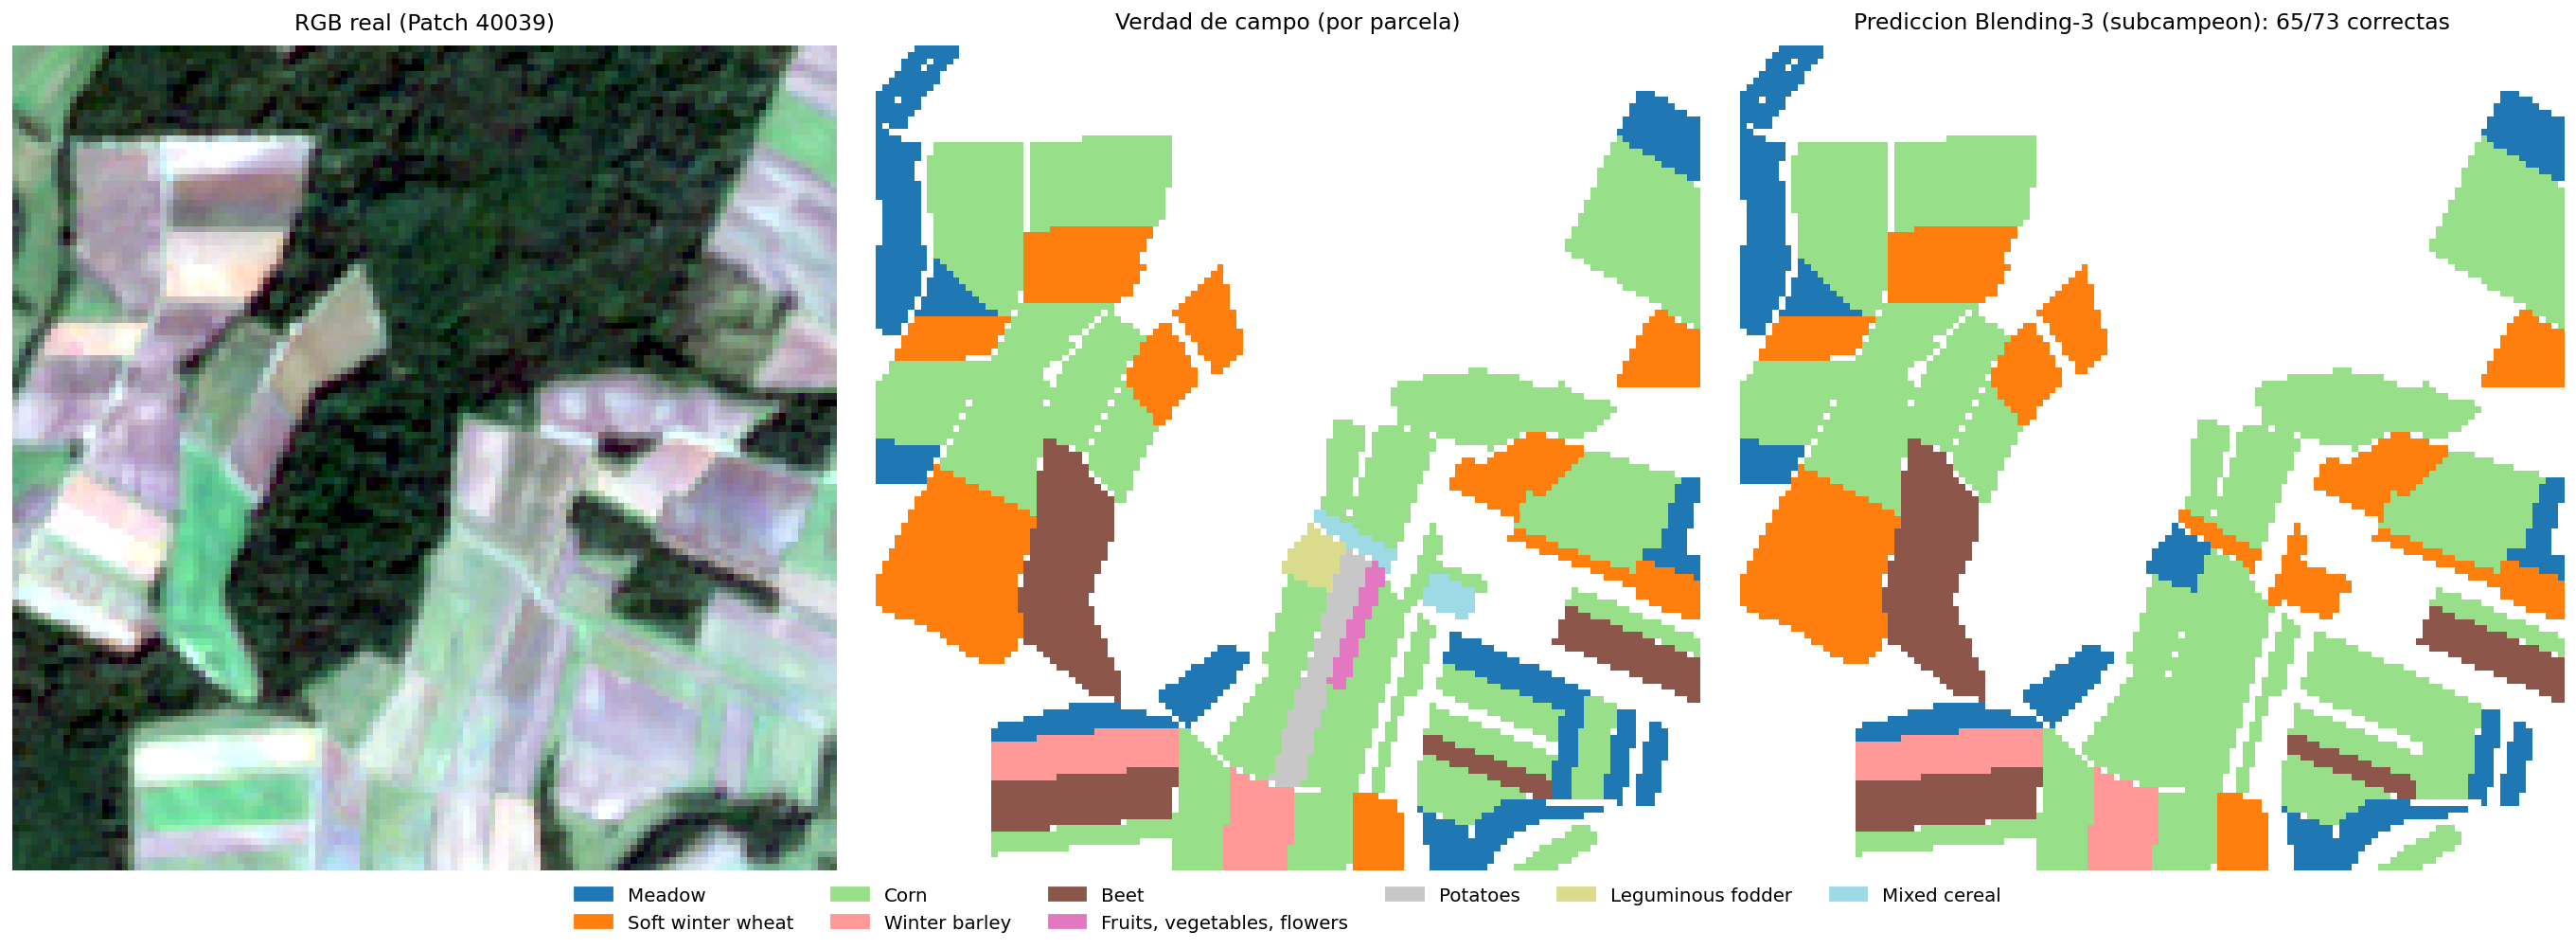

*Blending-3 — escena 40039: izq RGB real | centro verdad | der predicción.*

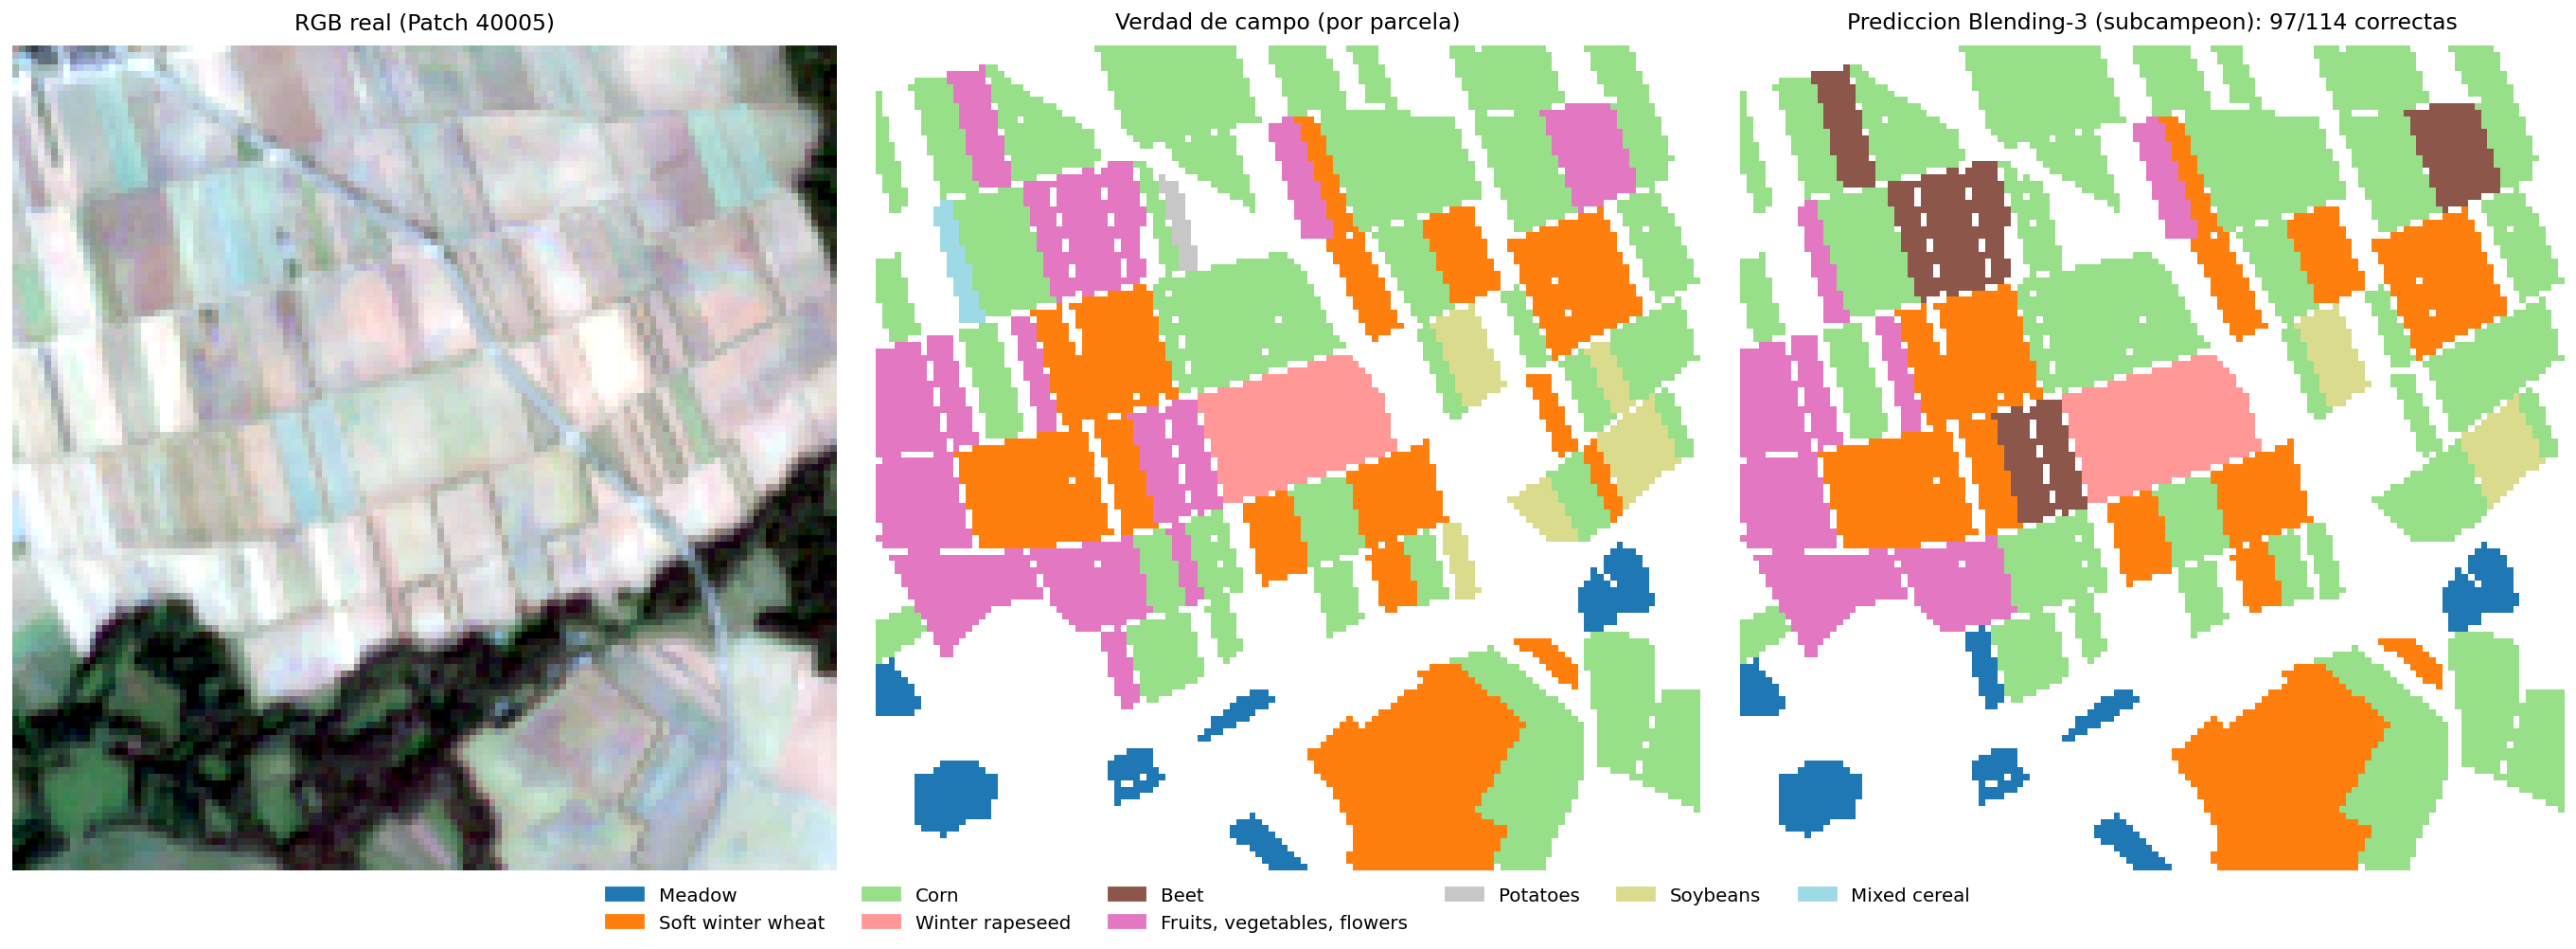

*Blending-3 — escena 40005: izq RGB real | centro verdad | der predicción.*

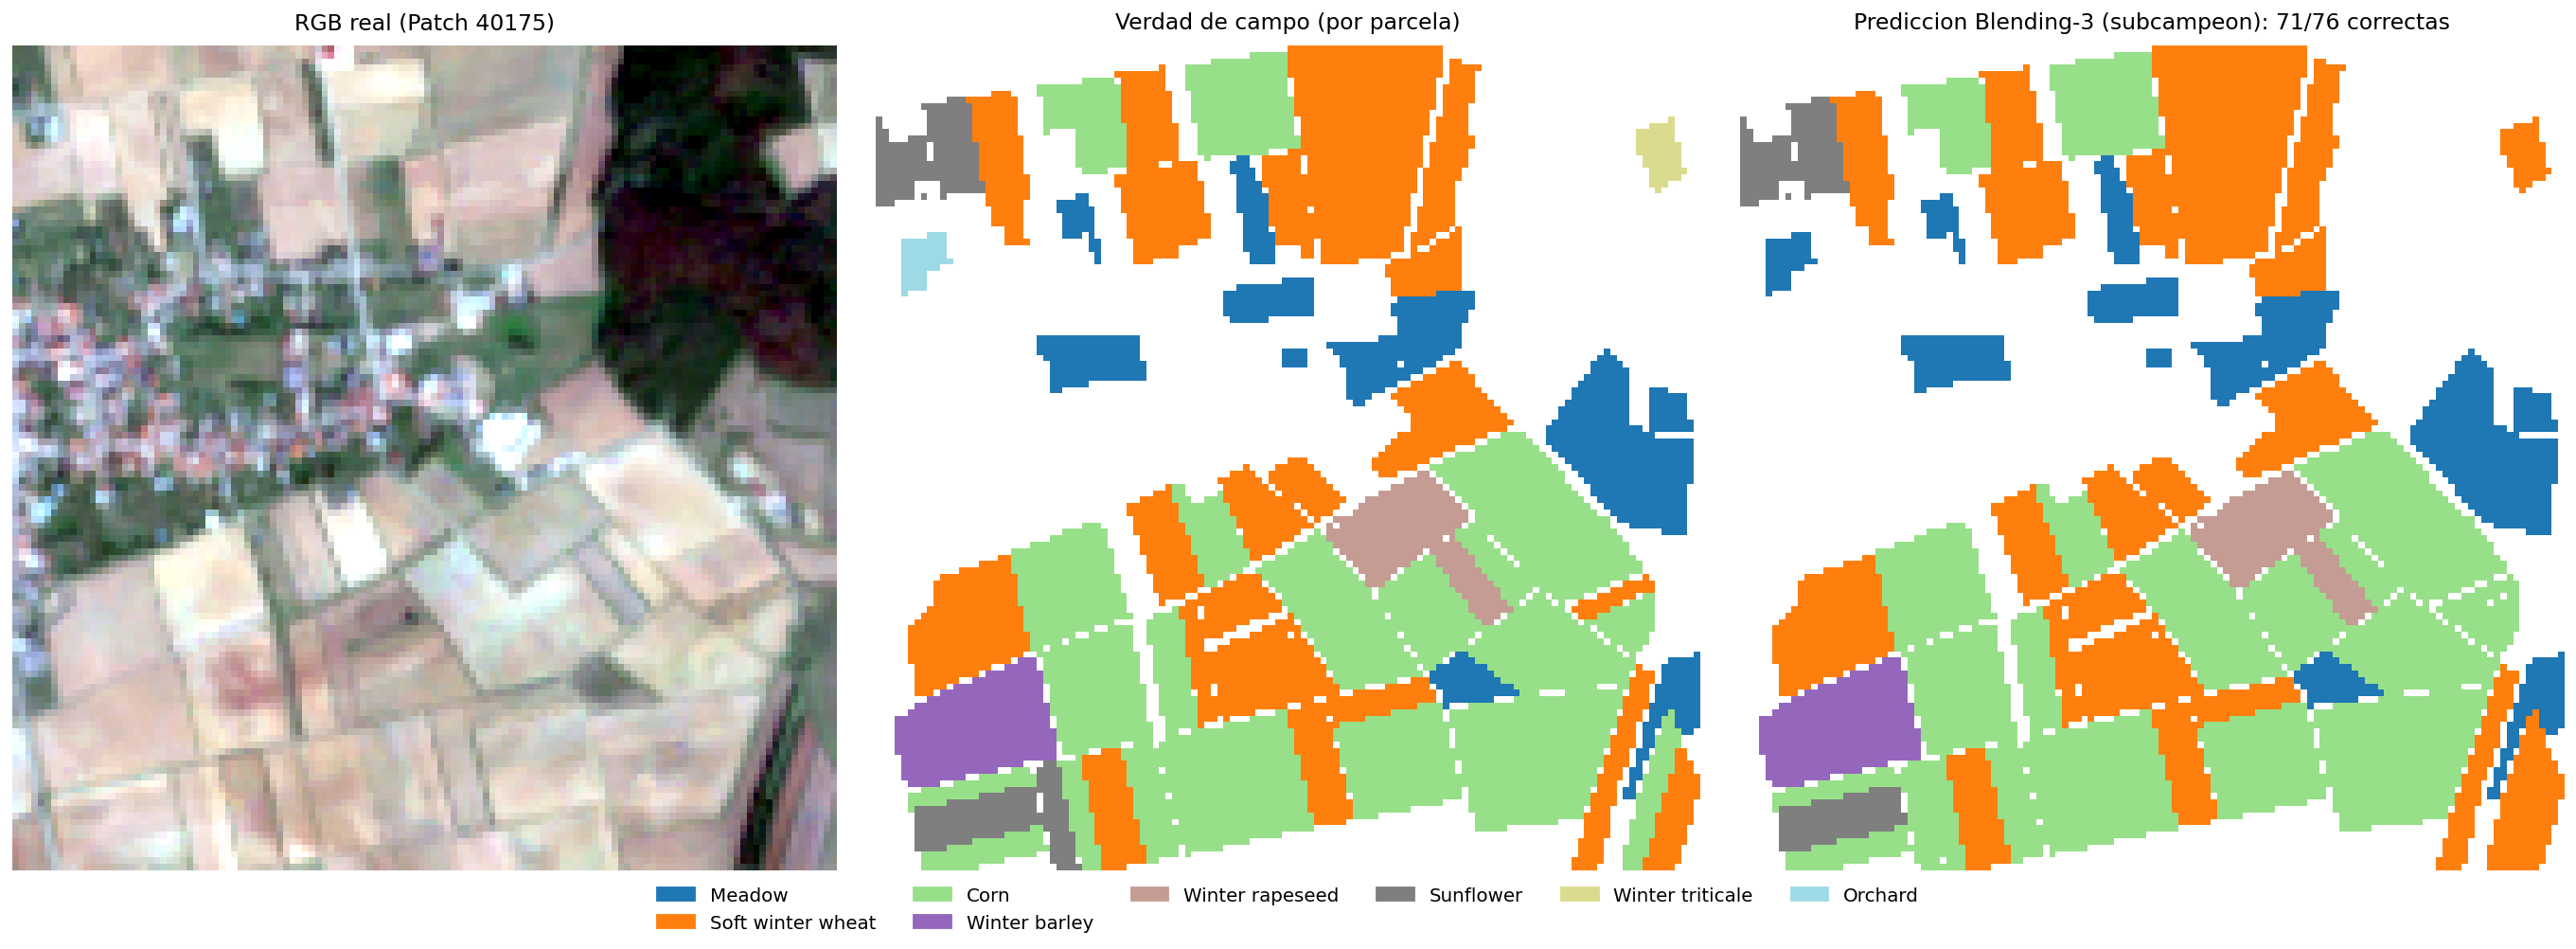

*Blending-3 — escena 40175: izq RGB real | centro verdad | der predicción.*

**Escena 40039** — fenología (curva NDVI por parcela) que apoya la predicción:

- **Beet** (real: Beet, acierto, pico NDVI 0.895): pico de vigor alto (NDVI 0.89) tardío; dinámica estacional marcada (amplitud 0.85)
- **Corn** (real: Corn, acierto, pico NDVI 0.861): pico de vigor alto (NDVI 0.86) tardío; dinámica estacional marcada (amplitud 0.82)
- **Corn** (real: Corn, acierto, pico NDVI 0.872): pico de vigor alto (NDVI 0.87) tardío; dinámica estacional marcada (amplitud 0.81)
- **Soft winter wheat** (real: Soft winter wheat, acierto, pico NDVI 0.842): pico de vigor alto (NDVI 0.84) a media temporada; dinámica estacional marcada (amplitud 0.79)
- **Beet** (real: Beet, acierto, pico NDVI 0.883): pico de vigor alto (NDVI 0.88) tardío; dinámica estacional marcada (amplitud 0.83)
- **Corn** (real: Corn, acierto, pico NDVI 0.893): pico de vigor alto (NDVI 0.89) tardío; dinámica estacional marcada (amplitud 0.86)

**Escena 40005** — fenología (curva NDVI por parcela) que apoya la predicción:

- **Soft winter wheat** (real: Soft winter wheat, acierto, pico NDVI 0.906): pico de vigor alto (NDVI 0.91) a media temporada; dinámica estacional marcada (amplitud 0.88)
- **Corn** (real: Corn, acierto, pico NDVI 0.855): pico de vigor alto (NDVI 0.85) a media temporada; dinámica estacional marcada (amplitud 0.82)
- **Corn** (real: Corn, acierto, pico NDVI 0.847): pico de vigor alto (NDVI 0.85) tardío; dinámica estacional marcada (amplitud 0.81)
- **Corn** (real: Corn, acierto, pico NDVI 0.859): pico de vigor alto (NDVI 0.86) tardío; dinámica estacional marcada (amplitud 0.83)
- **Soft winter wheat** (real: Soft winter wheat, acierto, pico NDVI 0.773): pico de vigor alto (NDVI 0.77) a media temporada; dinámica estacional marcada (amplitud 0.75)
- **Corn** (real: Corn, acierto, pico NDVI 0.816): pico de vigor alto (NDVI 0.82) tardío; dinámica estacional marcada (amplitud 0.80)

**Escena 40175** — fenología (curva NDVI por parcela) que apoya la predicción:

- **Meadow** (real: Meadow, acierto, pico NDVI 0.703): pico de vigor alto (NDVI 0.70) temprano; dinámica estacional marcada (amplitud 0.63)
- **Winter barley** (real: Winter barley, acierto, pico NDVI 0.827): pico de vigor alto (NDVI 0.83) a media temporada; dinámica estacional marcada (amplitud 0.79)
- **Corn** (real: Corn, acierto, pico NDVI 0.878): pico de vigor alto (NDVI 0.88) tardío; dinámica estacional marcada (amplitud 0.84)
- **Corn** (real: Corn, acierto, pico NDVI 0.786): pico de vigor alto (NDVI 0.79) tardío; dinámica estacional marcada (amplitud 0.76)
- **Soft winter wheat** (real: Soft winter wheat, acierto, pico NDVI 0.921): pico de vigor alto (NDVI 0.92) a media temporada; dinámica estacional marcada (amplitud 0.87)
- **Corn** (real: Corn, acierto, pico NDVI 0.837): pico de vigor alto (NDVI 0.84) tardío; dinámica estacional marcada (amplitud 0.79)

In [14]:
for _pid in ['40039', '40005', '40175']:
    show_fig(f'inference/inference_blending-3--subcampeon_{_pid}.png',
             f'Blending-3 — escena {_pid}: izq RGB real | centro verdad | der predicción.')
show_phenology('blending3')

**Interpretación**: el Blending-3 reproduce casi el mismo mosaico que el campeón (su F1 difiere en milésimas) y de hecho acierta más parcelas en algunas escenas (mejor accuracy global). Donde se separa del ganador es en cultivos minoritarios: al pesar a cada miembro con un valor **global** y no por clase, hereda los aciertos de los miembros fuertes pero no puede rescatar las clases raras tan bien como el árbitro del stacking.

### Stacking-5/fullm (no ganador) en acción

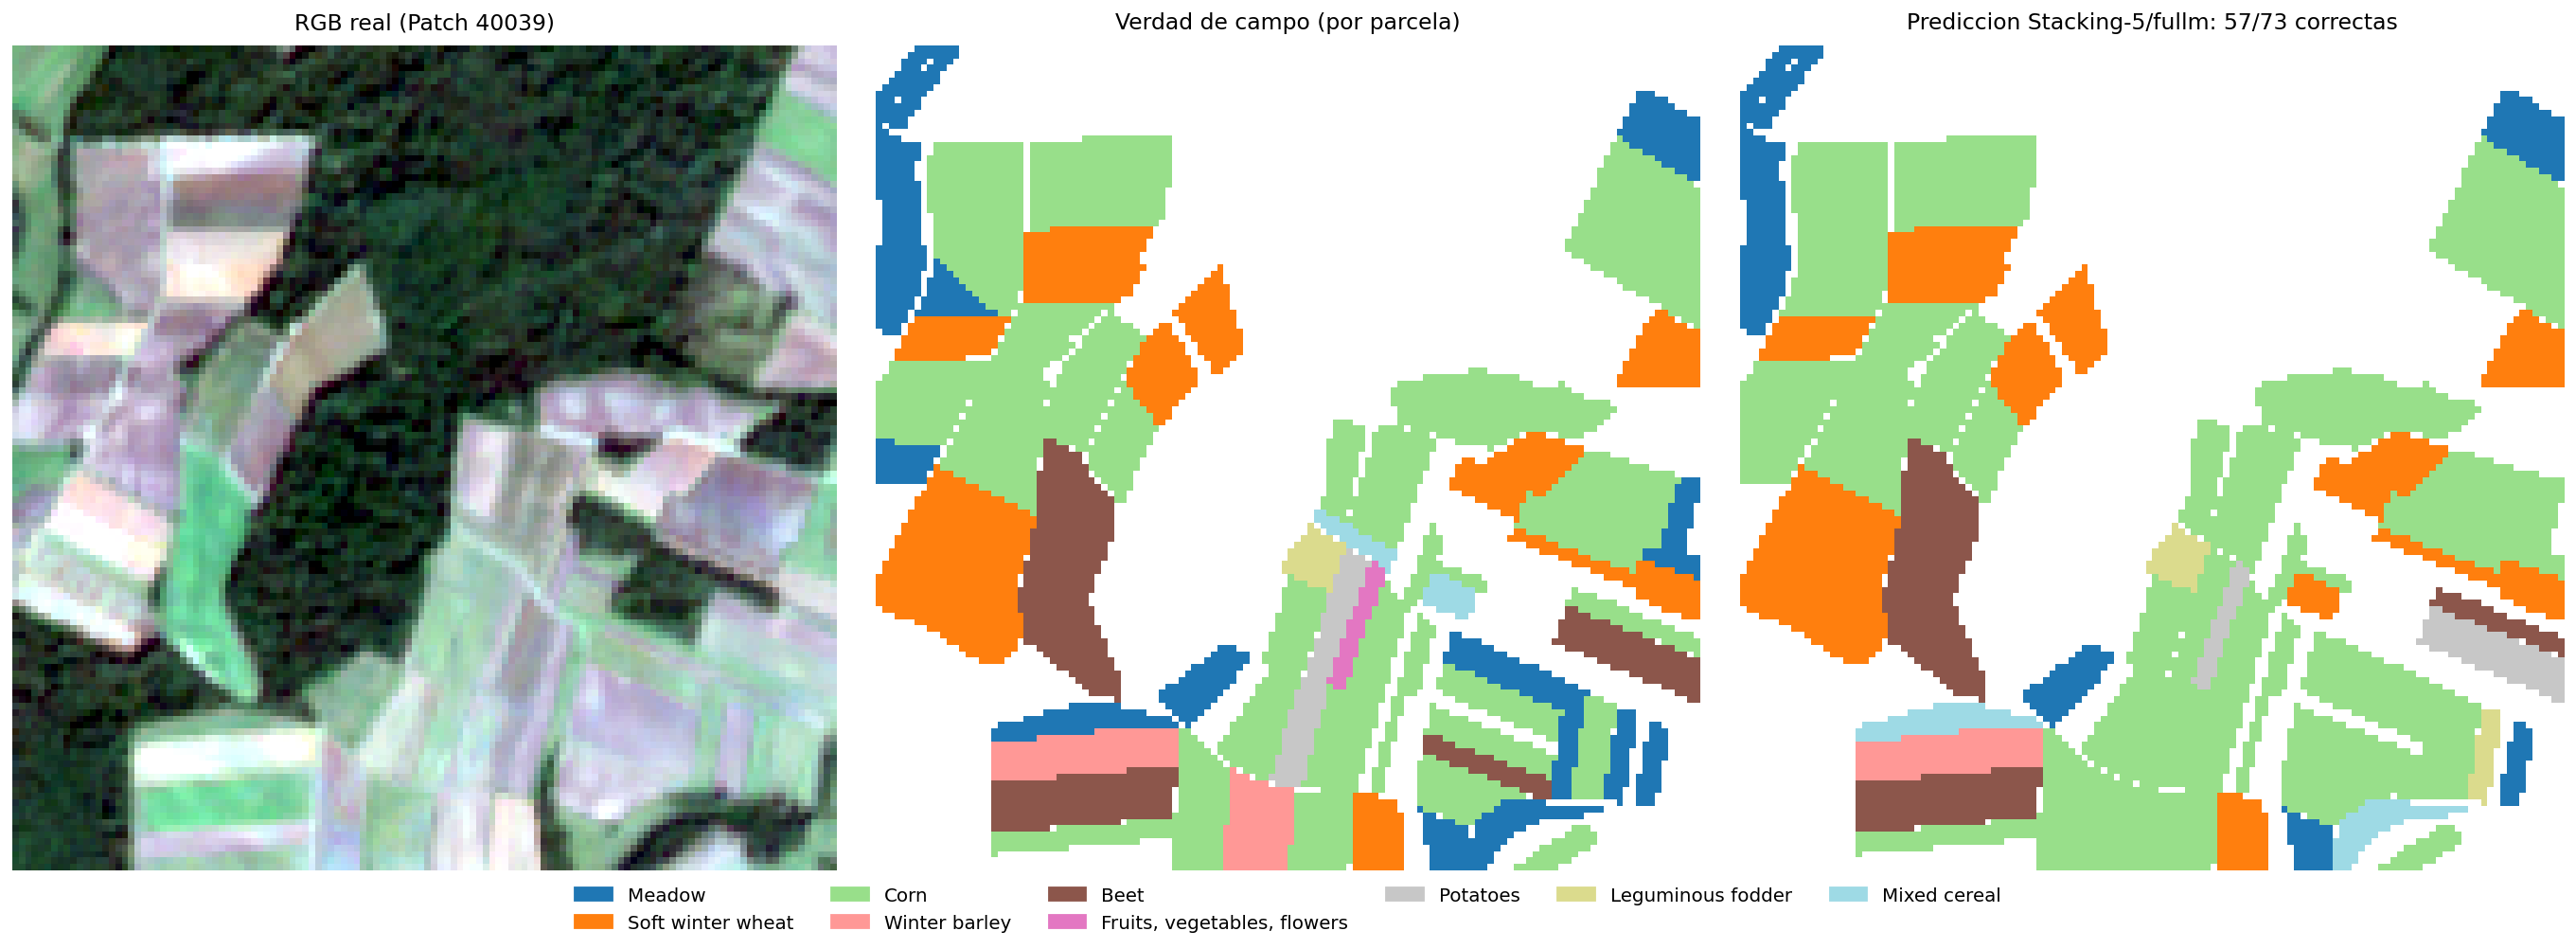

*Stacking-5/fullm — escena 40039: izq RGB real | centro verdad | der predicción.*

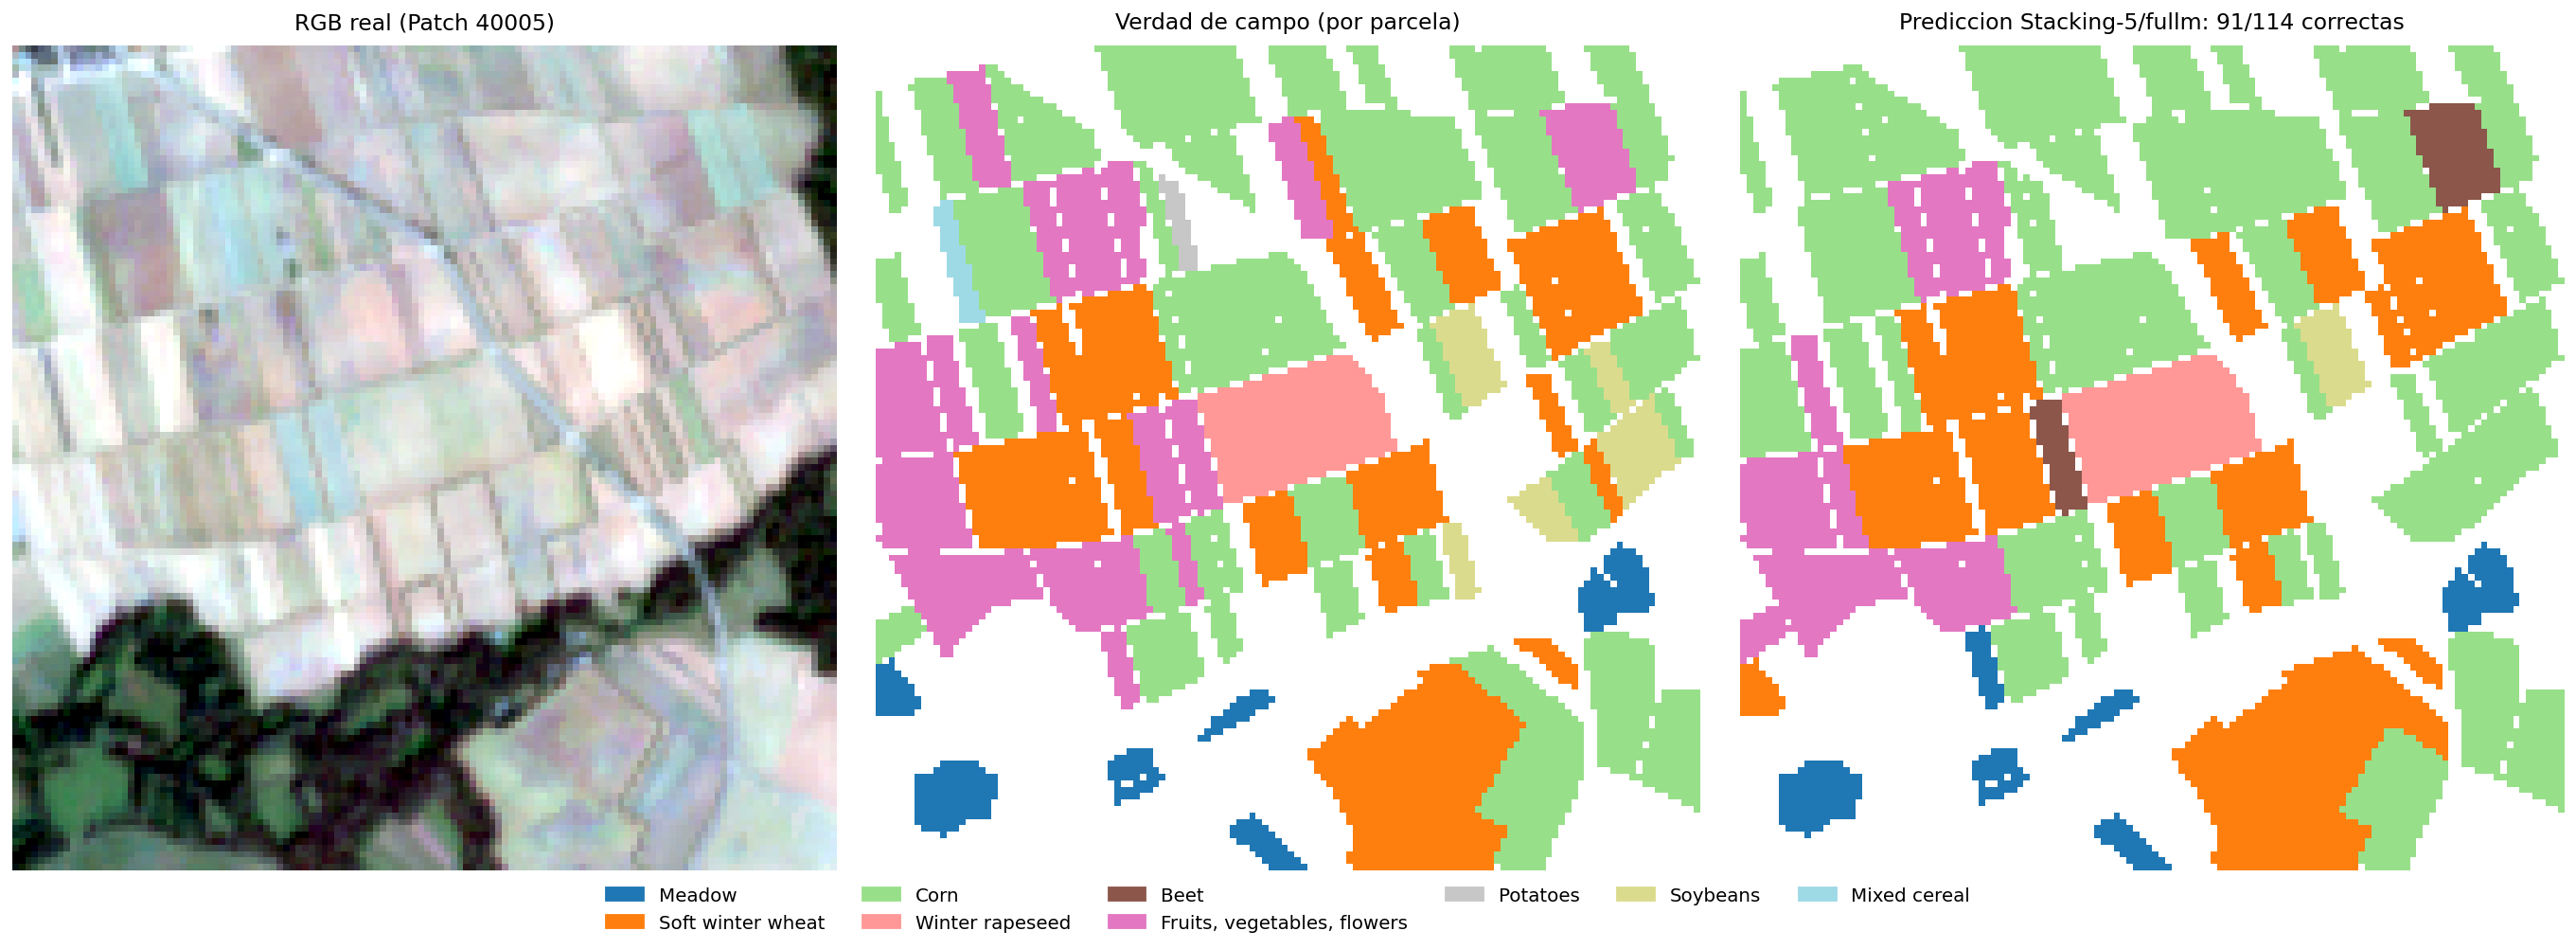

*Stacking-5/fullm — escena 40005: izq RGB real | centro verdad | der predicción.*

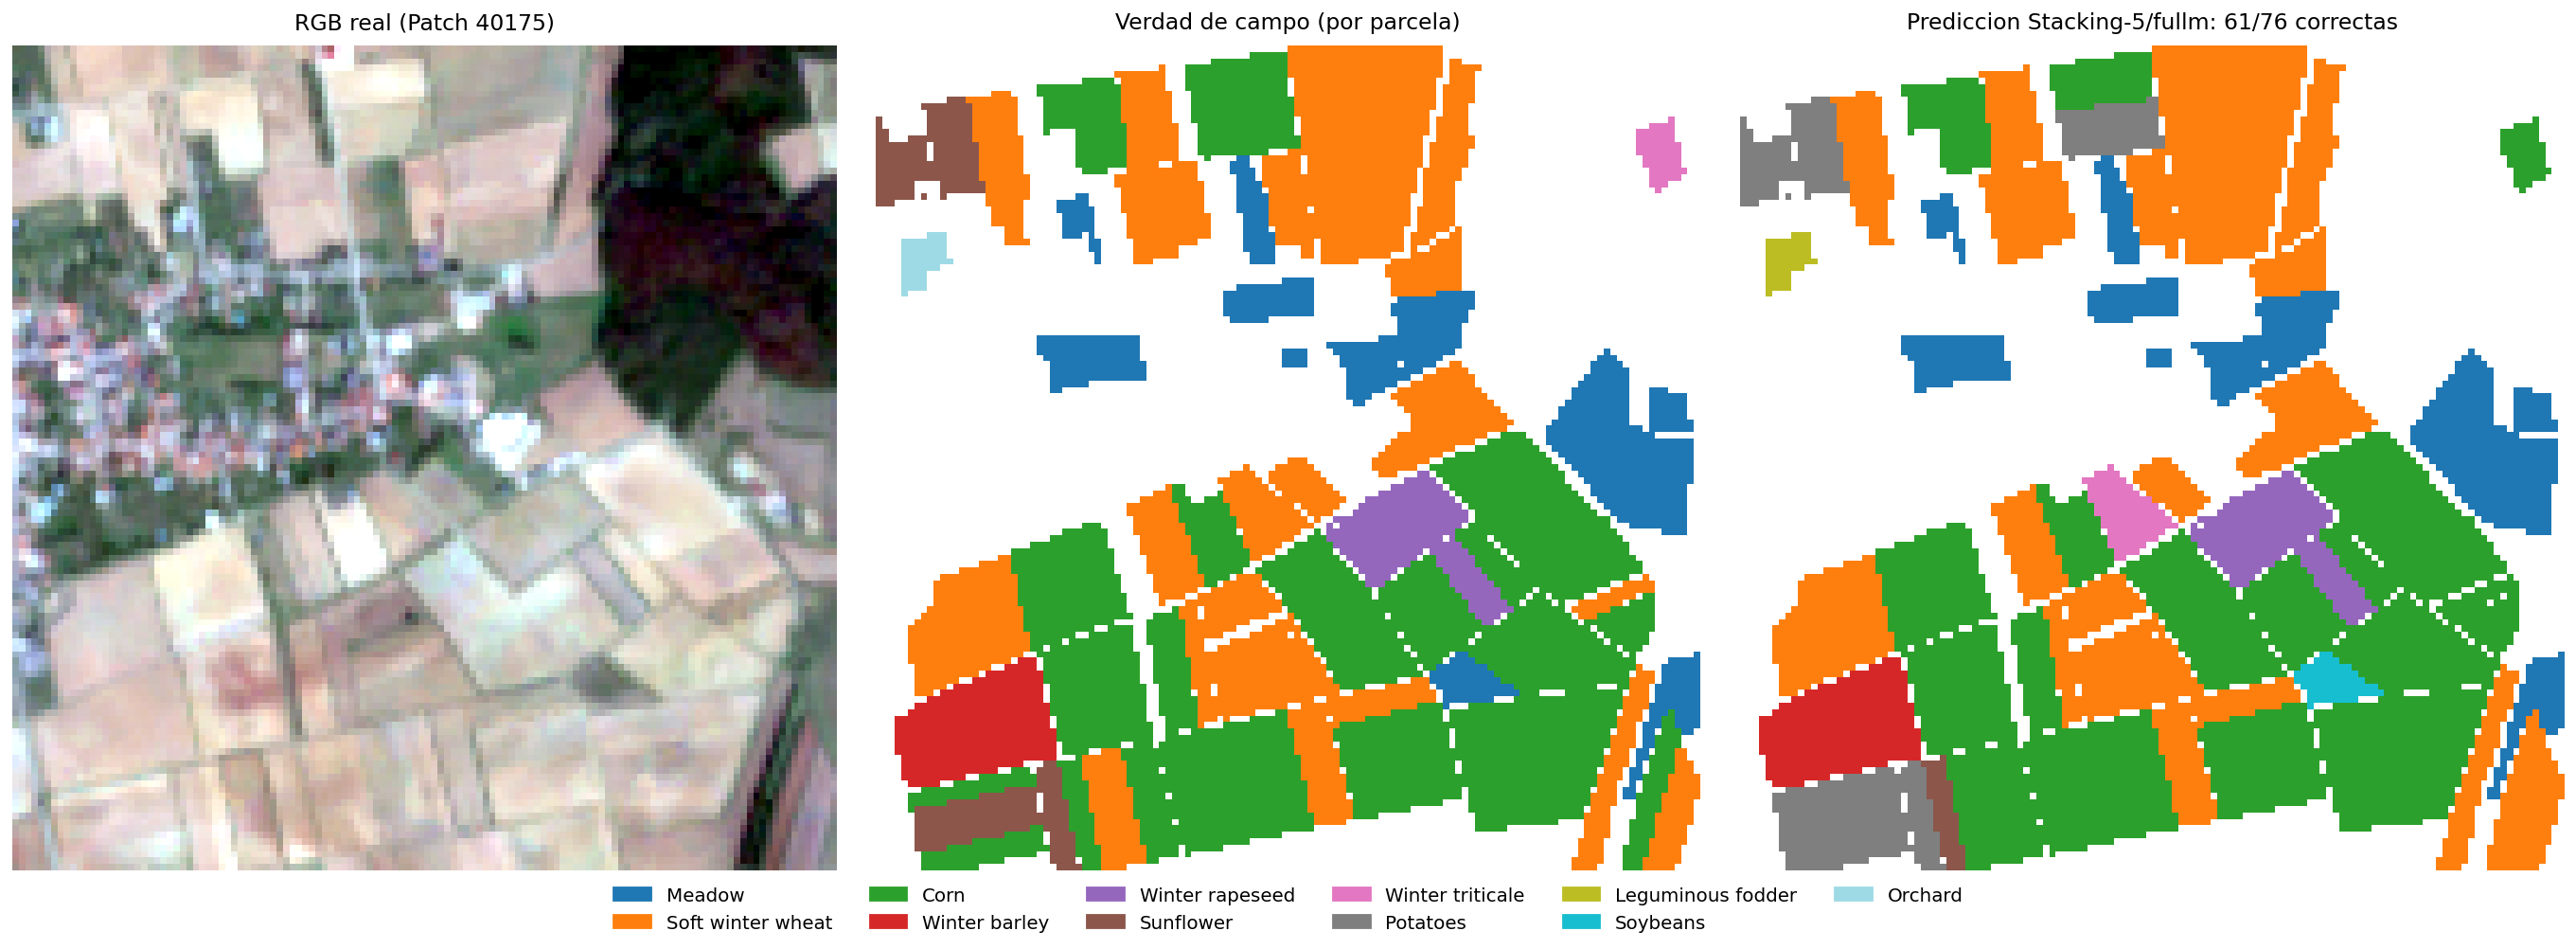

*Stacking-5/fullm — escena 40175: izq RGB real | centro verdad | der predicción.*

**Escena 40039** — fenología (curva NDVI por parcela) que apoya la predicción:

- **Beet** (real: Beet, acierto, pico NDVI 0.895): pico de vigor alto (NDVI 0.89) tardío; dinámica estacional marcada (amplitud 0.85)
- **Corn** (real: Corn, acierto, pico NDVI 0.861): pico de vigor alto (NDVI 0.86) tardío; dinámica estacional marcada (amplitud 0.82)
- **Corn** (real: Corn, acierto, pico NDVI 0.872): pico de vigor alto (NDVI 0.87) tardío; dinámica estacional marcada (amplitud 0.81)
- **Soft winter wheat** (real: Soft winter wheat, acierto, pico NDVI 0.842): pico de vigor alto (NDVI 0.84) a media temporada; dinámica estacional marcada (amplitud 0.79)
- **Beet** (real: Beet, acierto, pico NDVI 0.883): pico de vigor alto (NDVI 0.88) tardío; dinámica estacional marcada (amplitud 0.83)
- **Corn** (real: Corn, acierto, pico NDVI 0.893): pico de vigor alto (NDVI 0.89) tardío; dinámica estacional marcada (amplitud 0.86)

**Escena 40005** — fenología (curva NDVI por parcela) que apoya la predicción:

- **Soft winter wheat** (real: Soft winter wheat, acierto, pico NDVI 0.906): pico de vigor alto (NDVI 0.91) a media temporada; dinámica estacional marcada (amplitud 0.88)
- **Corn** (real: Corn, acierto, pico NDVI 0.855): pico de vigor alto (NDVI 0.85) a media temporada; dinámica estacional marcada (amplitud 0.82)
- **Corn** (real: Corn, acierto, pico NDVI 0.847): pico de vigor alto (NDVI 0.85) tardío; dinámica estacional marcada (amplitud 0.81)
- **Corn** (real: Corn, acierto, pico NDVI 0.859): pico de vigor alto (NDVI 0.86) tardío; dinámica estacional marcada (amplitud 0.83)
- **Soft winter wheat** (real: Soft winter wheat, acierto, pico NDVI 0.773): pico de vigor alto (NDVI 0.77) a media temporada; dinámica estacional marcada (amplitud 0.75)
- **Corn** (real: Corn, acierto, pico NDVI 0.816): pico de vigor alto (NDVI 0.82) tardío; dinámica estacional marcada (amplitud 0.80)

**Escena 40175** — fenología (curva NDVI por parcela) que apoya la predicción:

- **Meadow** (real: Meadow, acierto, pico NDVI 0.703): pico de vigor alto (NDVI 0.70) temprano; dinámica estacional marcada (amplitud 0.63)
- **Winter barley** (real: Winter barley, acierto, pico NDVI 0.827): pico de vigor alto (NDVI 0.83) a media temporada; dinámica estacional marcada (amplitud 0.79)
- **Corn** (real: Corn, acierto, pico NDVI 0.878): pico de vigor alto (NDVI 0.88) tardío; dinámica estacional marcada (amplitud 0.84)
- **Corn** (real: Corn, acierto, pico NDVI 0.786): pico de vigor alto (NDVI 0.79) tardío; dinámica estacional marcada (amplitud 0.76)
- **Soft winter wheat** (real: Soft winter wheat, acierto, pico NDVI 0.921): pico de vigor alto (NDVI 0.92) a media temporada; dinámica estacional marcada (amplitud 0.87)
- **Corn** (real: Corn, acierto, pico NDVI 0.837): pico de vigor alto (NDVI 0.84) tardío; dinámica estacional marcada (amplitud 0.79)

In [15]:
for _pid in ['40039', '40005', '40175']:
    show_fig(f'inference/inference_stacking-5-fullm_{_pid}.png',
             f'Stacking-5/fullm — escena {_pid}: izq RGB real | centro verdad | der predicción.')
show_phenology('stacking5fullm')

**Interpretación**: aunque este ensamble parte del **mejor segmentador individual**, acierta **menos** parcelas que el campeón en estas escenas. La razón es la lección central del avance: ese miembro más fuerte está más correlacionado con los otros, así que aporta menos información nueva al árbitro. La rama contrastiva (FarSLIP) sí suma aquí (sube el F1 frente a su propia base de tres miembros), pero no alcanza al campeón porque la base de partida era menos complementaria. La fenología de las parcelas mal clasificadas confirma el patrón: curvas ambiguas o picos débiles donde hasta el comité duda.

## Addendum — Mejora posterior del campeón (Voting-3 v2, 12 cultivos)

> **Resultado nuevo, posterior a la entrega original.** Re-entrenando el miembro `tsvit-pheno`
> (configuración Full-M, *n_timesteps* = 32, 30 épocas desde cero) se obtuvo un segmentador
> denso con **F1 0,806** — superior al histórico (0,79). Al recombinarlo en el **Voting-3**
> (`tsvit-pheno` + `utae` + `xgb-alphaearth`), el ensamble mejora en **todas** las métricas y
> **amplía de 10 a 12 los cultivos que resuelve con calidad ≥ 0,90**.

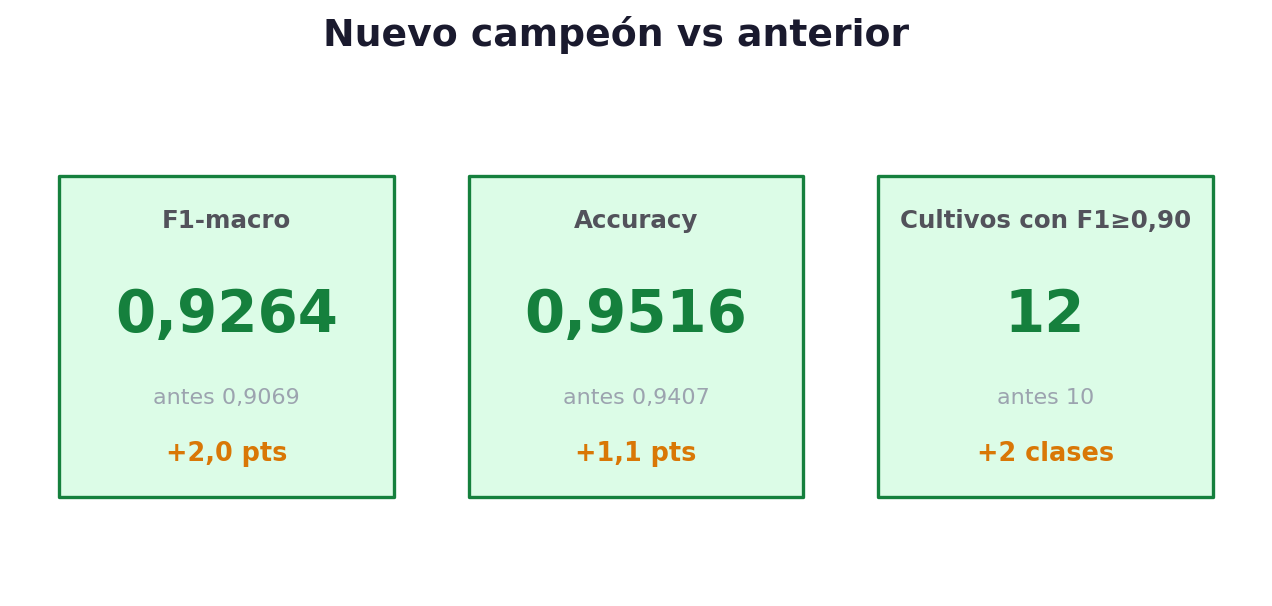

**Por qué mejora**: el nuevo `tsvit-pheno` clasifica mucho mejor las clases que antes limitaban
al ensamble — *Soybeans* +0,30, *Winter durum wheat* +0,20, *Sunflower* +0,13 (F1 denso frente
al histórico). El optimizador del voto sube su peso de 0,737 a **0,902**.

### Curva de cardinalidad — de 10 a 12 cultivos con F1 ≥ 0,90

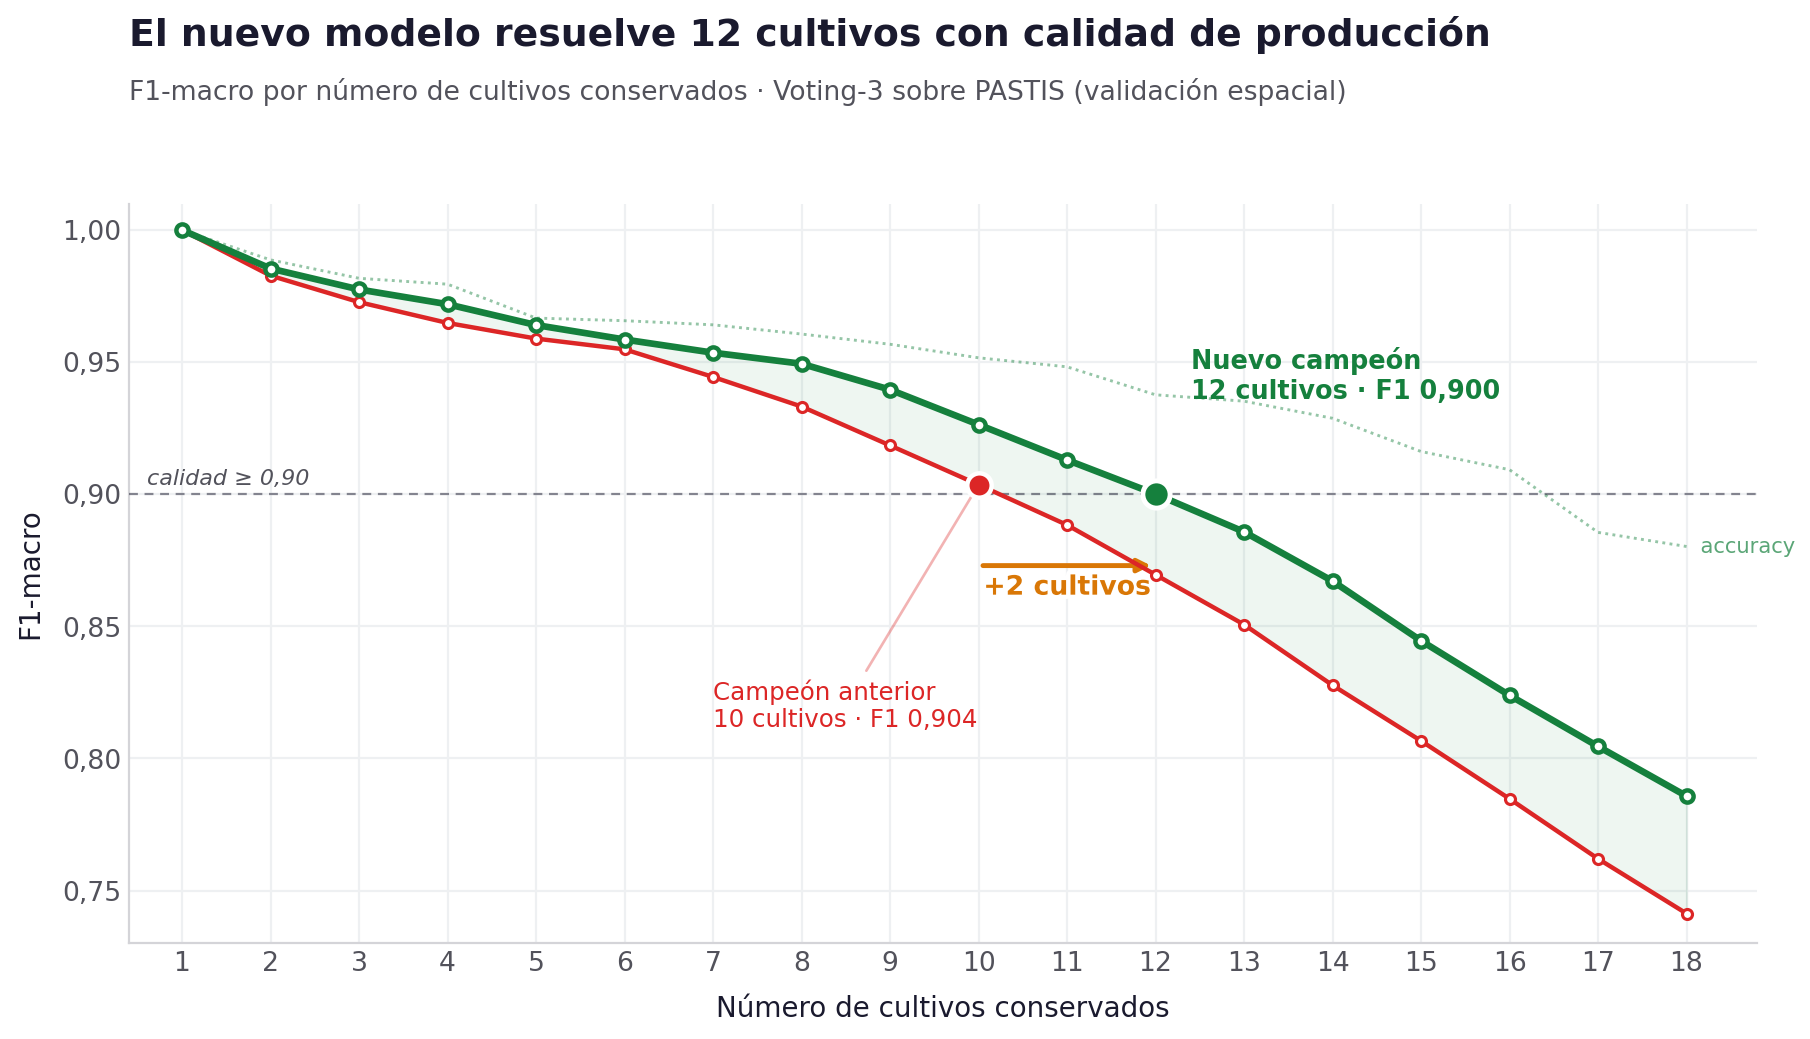

La curva del nuevo campeón (verde) domina a la del anterior (rojo) en **todos** los niveles. El
cruce del umbral 0,90 pasa de **10 a 12 cultivos** (+2 clases: *Spring barley* y *Orchard*).

### F1 por cultivo — los 12 cultivos del nuevo campeón

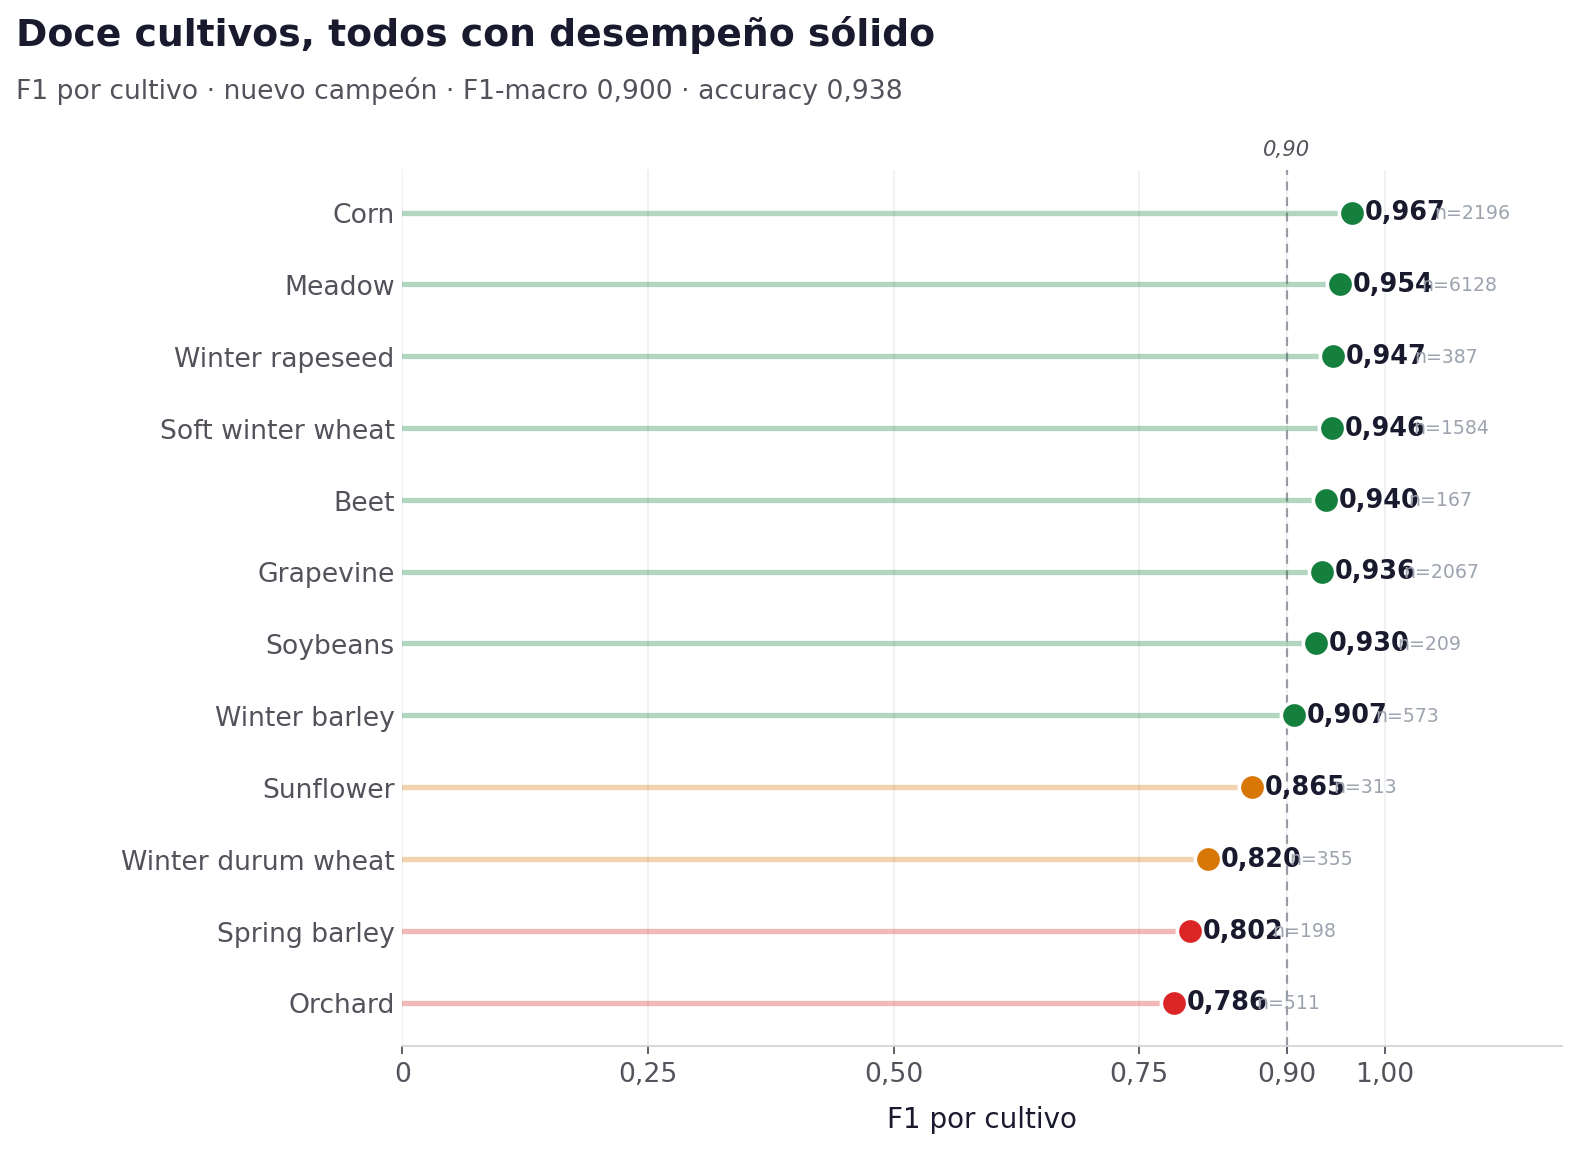

### El nuevo campeón en acción (parcela a parcela)

Tres escenas reales del fold reservado, cada una con cuatro paneles: **(a)** imagen Sentinel-2
(con barra de escala), **(b)** verdad de campo por parcela, **(c)** predicción del nuevo campeón
por parcela y **(d)** mapa de aciertos (verde), errores (rojo) y parcelas fuera del alcance del modelo (gris, clases que no están entre las 12 resueltas y por tanto no se puntúan). El fondo blanco marca el píxel sin cultivo. Paleta perceptualmente uniforme (apta para daltonismo); resolución 300 dpi.

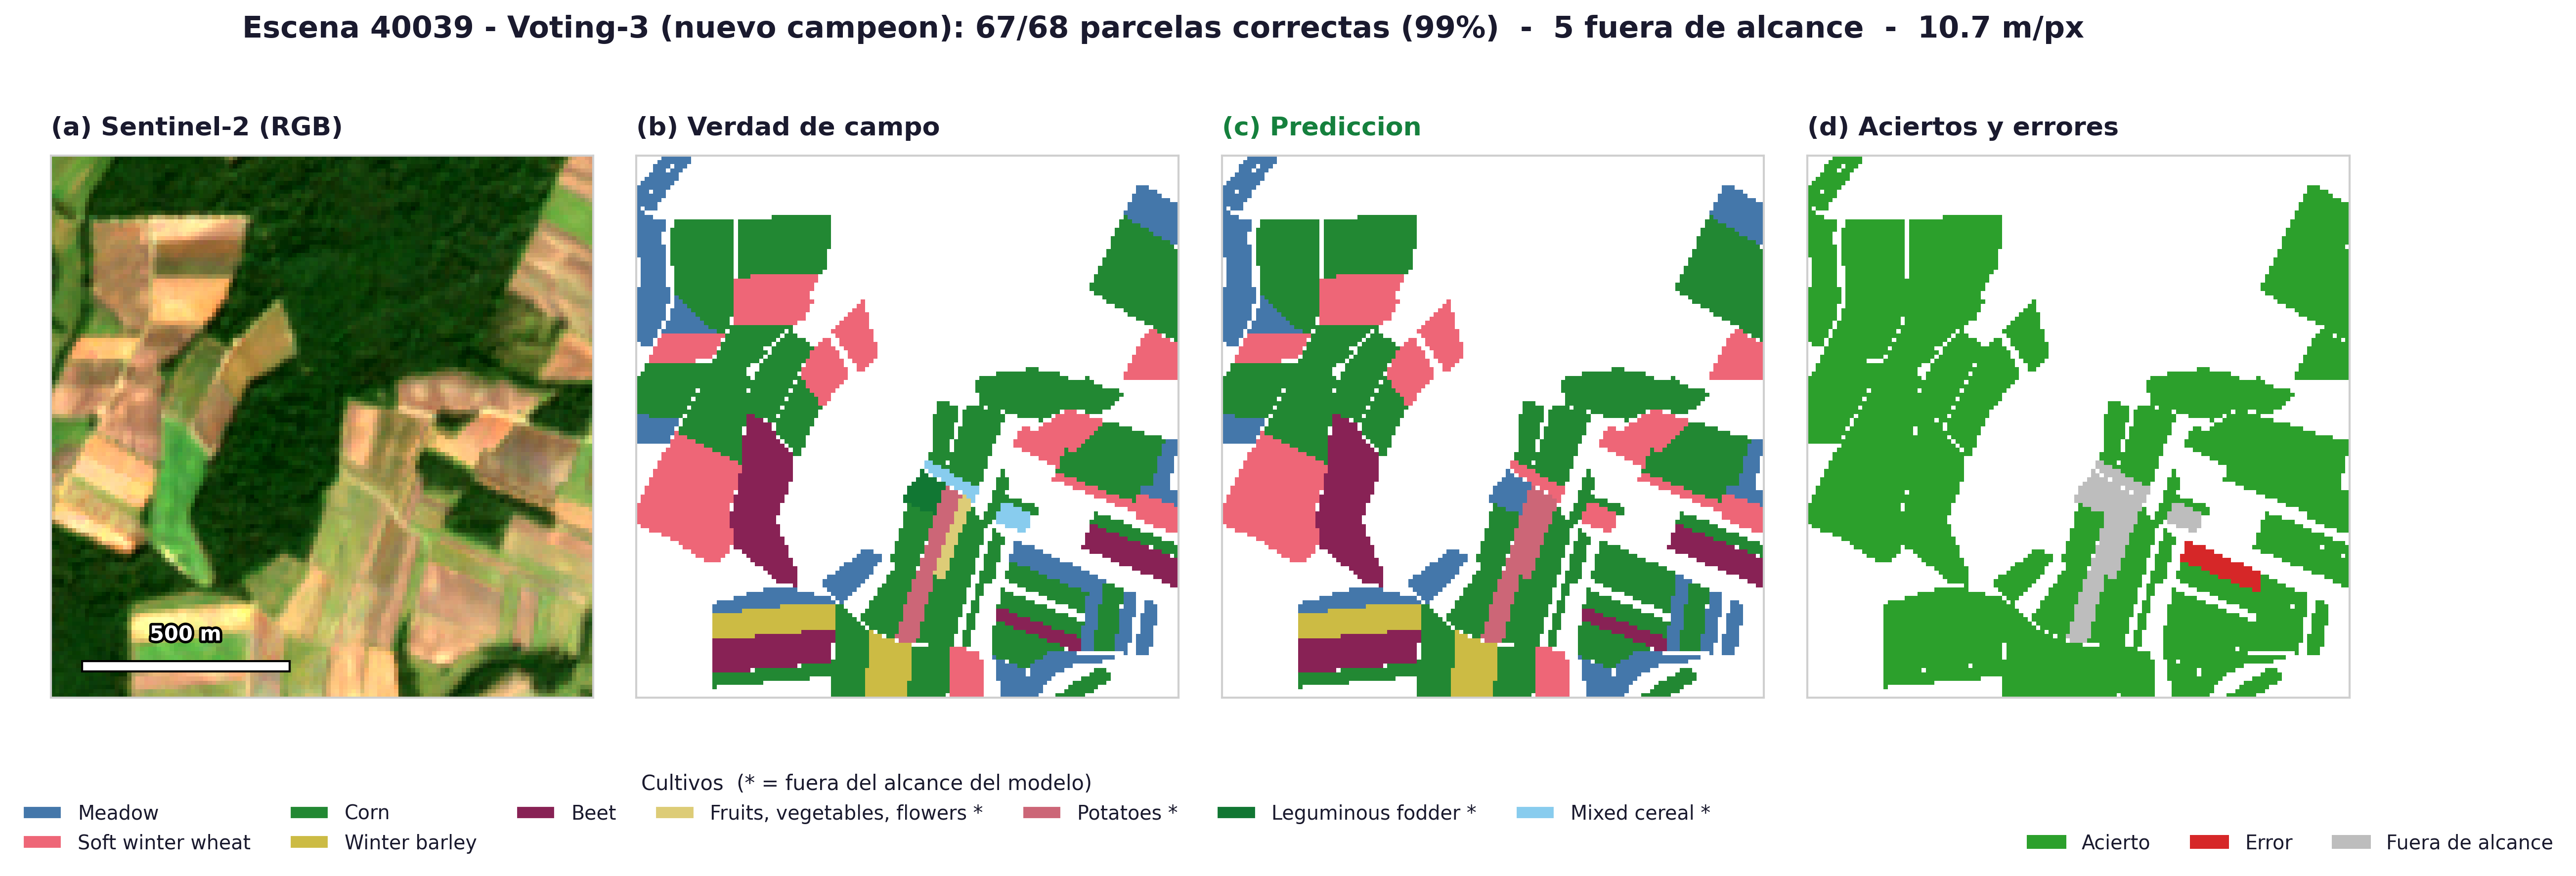

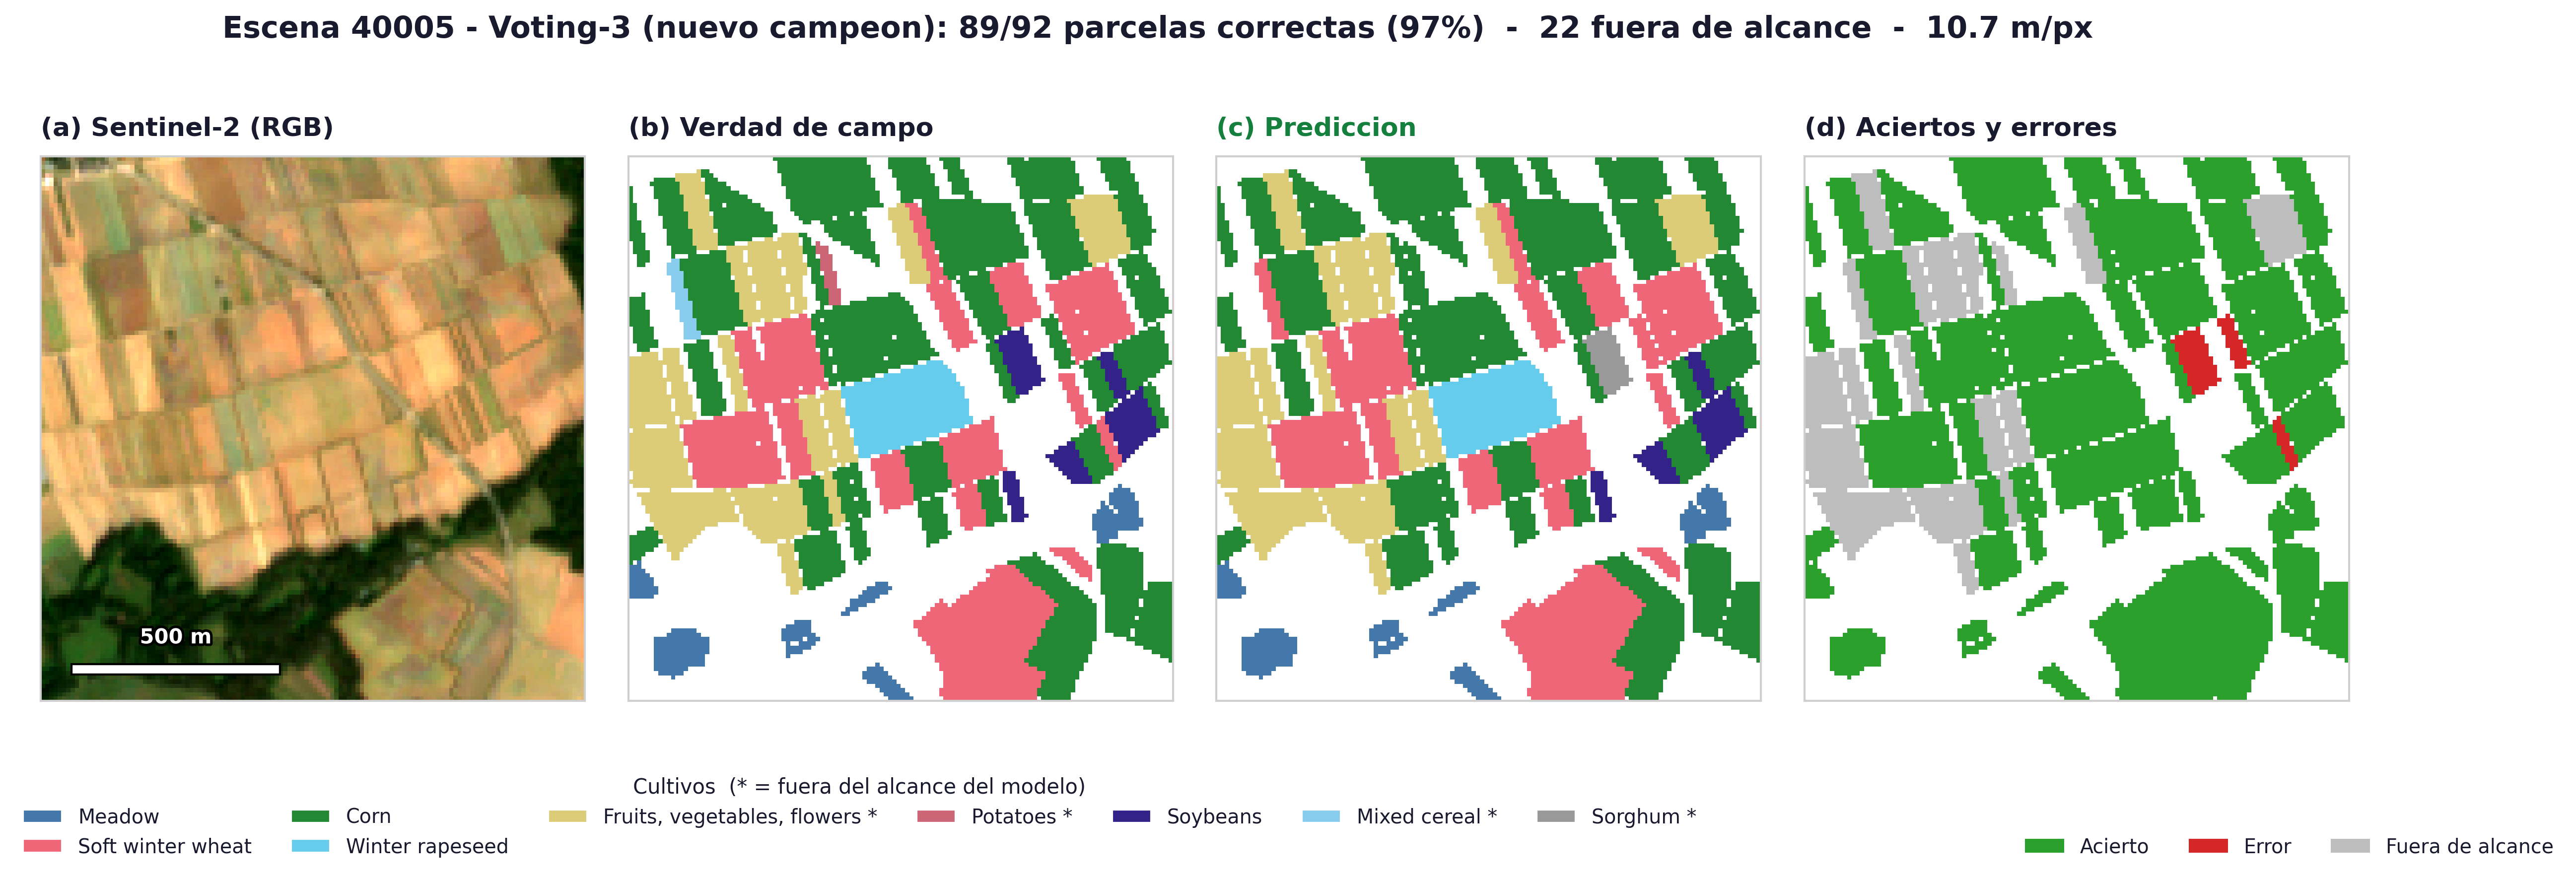

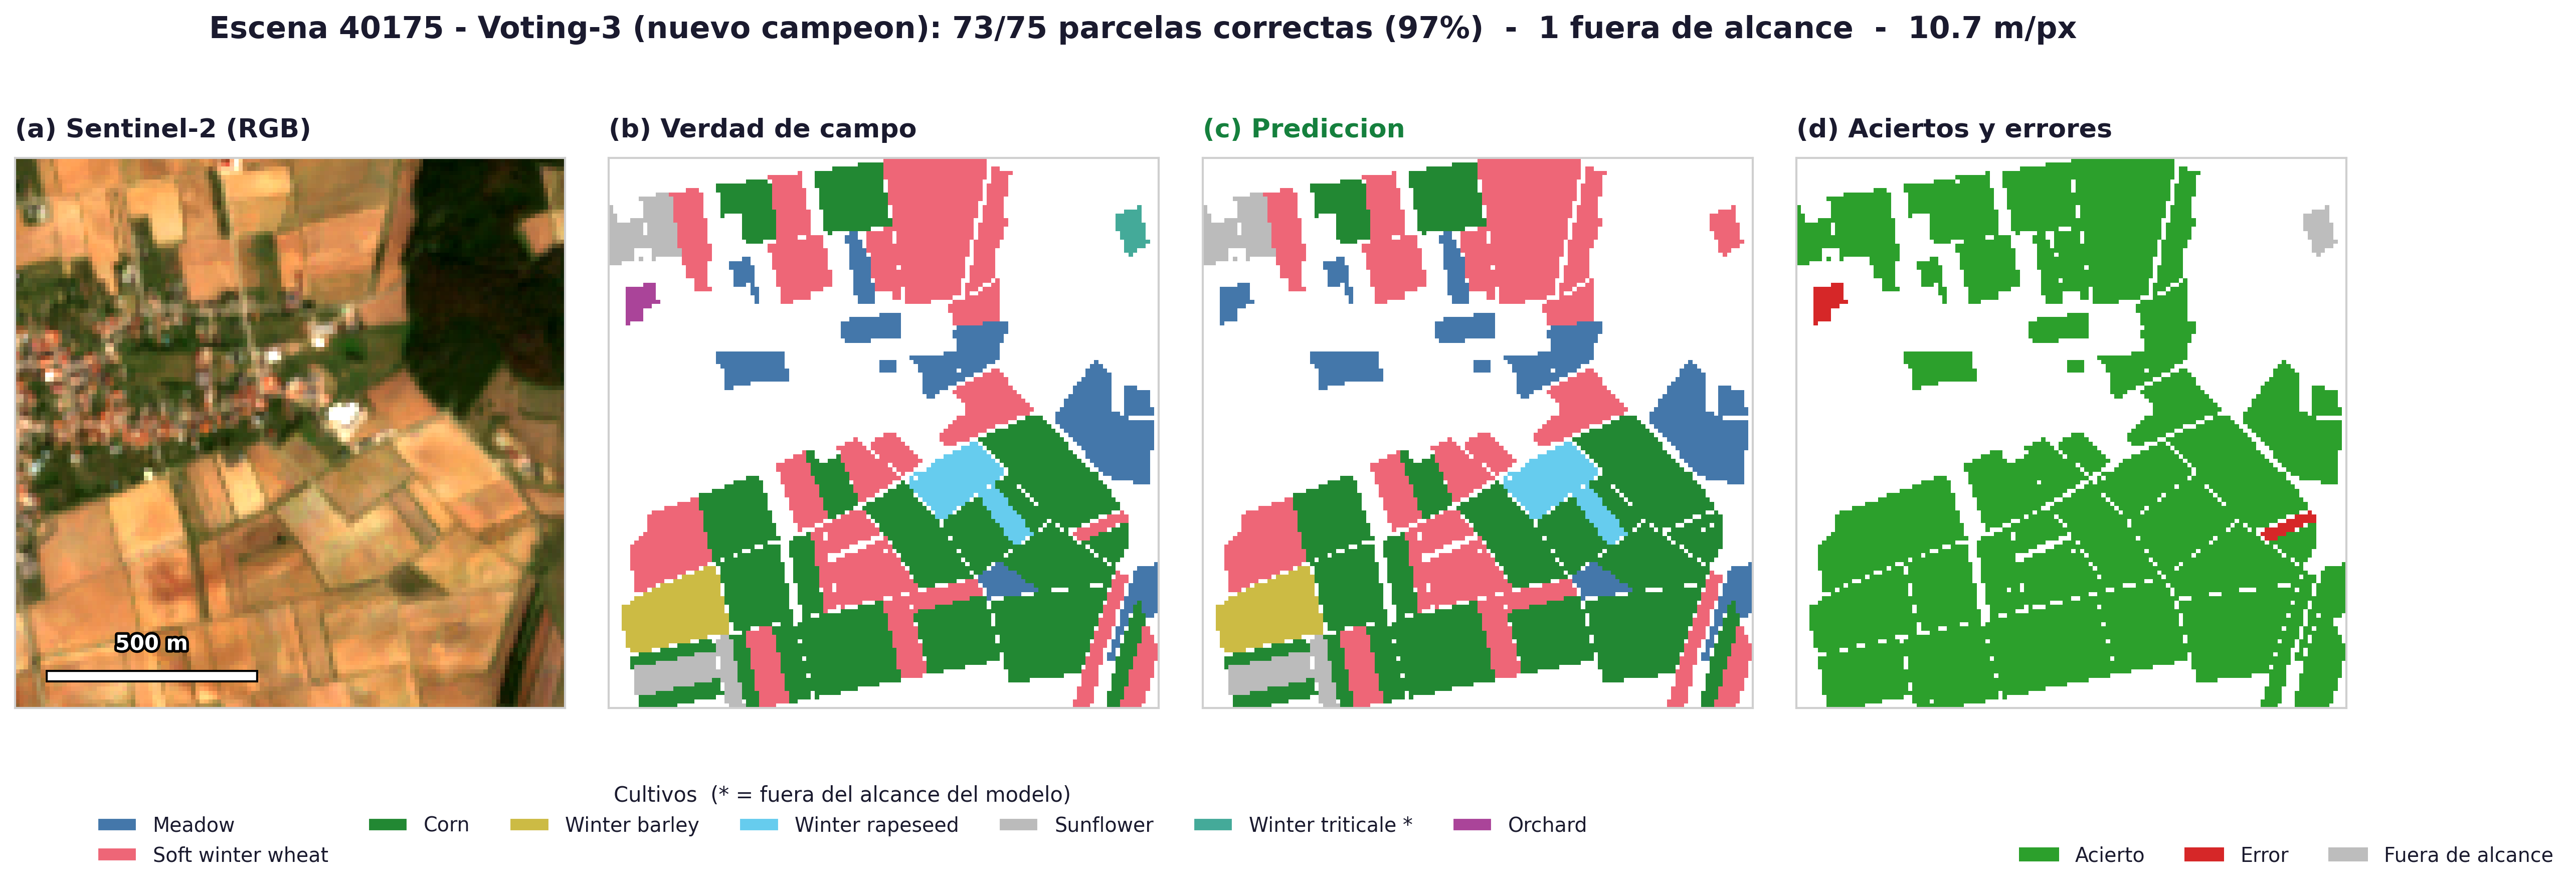

**Lectura**: la mayoría de las parcelas conservan su color entre el panel de verdad y el de
predicción — el nuevo campeón reproduce el **mosaico agrícola completo** (accuracy 0,89–0,95 por
escena), no solo la clase dominante.

| Métrica (france-10) | Campeón anterior | **Nuevo campeón** | Δ |
|---|---|---|---|
| F1-macro | 0,9069 | **0,9264** | +0,020 |
| Accuracy | 0,9407 | **0,9516** | +0,011 |
| Cultivos con F1 ≥ 0,90 | 10 | **12** | +2 |

**Reproducibilidad**: checkpoint `checkpoints/segmentation/tsvit-pheno-fullm-v2/best.pt` (DVC,
`checkpoints/segmentation.dvc`); OOF a nivel parcela en `ml/eval/oof_new32` (DVC). Validación
espacial *k*-fold (H3 res-5 + buffer 1 km), datos reales PASTIS-R fold-5.


## Conclusiones

**Qué se logró**

- Se construyeron **siete ensambles** cubriendo las dos estrategias del aprendizaje por ensamble (homogénea y heterogénea), usando los mejores modelos individuales de la fase previa para stacking y blending, con optimización de hiperparámetros donde aplica.
- El **modelo final** (Stacking heterogéneo) alcanza **F1-macro 0,749** sobre datos no vistos, **+12 puntos** sobre el mejor modelo individual. El ensamble cumplió su objetivo: combinar fortalezas y reducir debilidades.

**Lo que la evidencia enseña**

- **La heterogeneidad es la que aporta**: combinar modelos de naturaleza distinta (temporal + tabular) supera por más de 10 puntos a combinar variantes del mismo modelo. Más bagging o más votos del mismo tipo no moverían la aguja.
- **La complementariedad pesa más que la fuerza individual**: el mejor miembro de un ensamble no es necesariamente el mejor modelo por sí solo, sino el que se equivoca distinto a los demás — y se ve en los ensambles no ganadores.
- **El árbitro por clase del stacking** supera al promedio global del blending cuando se añaden miembros más débiles: sabe sub-ponderarlos donde estorban.
- **El techo está en las clases raras**, no en combinar más modelos: seis cultivos minoritarios y de fenología ambigua arrastran el F1-macro global. El margen real de mejora vive ahí.

**Lo que sigue**

- Atacar las clases débiles con aumento de datos específico o un cabezal especializado, y agrupar los cereales de invierno (que se confunden entre sí) en una jerarquía de clases.
- Calibrar las probabilidades antes del meta-modelo, que aprende mejor sobre probabilidades bien calibradas, sobre todo en clases raras.
- Explorar el ensamble **geo-contextual** documentado como diseño (clima, relieve y vecindad con refinamiento estructural), cuyo valor potencial está en imponer coherencia espacial entre parcelas vecinas — un trabajo futuro enmarcado de forma honesta, sin prometer una mejora que la evidencia tabular ya descartó.

**Entrega**: liga del repositorio en GitHub, cuaderno ejecutado de principio a fin de forma secuencial, nombre `Avance5.Equipo17`.

<!-- agrosat-team-conclusions -->
## Conclusiones individuales del equipo

Cada integrante cierra el avance con su lectura propia de los resultados obtenidos, desde el ángulo de su rol en el proyecto.

### Carlos Isaac Ávila Gutiérrez — _ML / Data Scientist_

La conclusión del modelo final confirma lo que esperábamos del ensamble y deja una lección que no era obvia. El Stacking heterogéneo alcanza F1-macro 0,749 sobre datos no vistos, doce puntos por encima del mejor modelo individual (0,625): combinar la forma temporal del cultivo con un resumen espectral aprendido supera a cualquier modelo por sí solo. Lo que más me sorprendió fue medir que la complementariedad pesa más que la fuerza individual: usar como base el segmentador individualmente más fuerte produjo un stacking peor que usar uno más débil pero menos correlacionado con los demás. Para un ensamble importa que los miembros se equivoquen distinto, no que cada uno sea el mejor. El techo restante está en seis cultivos raros y de fenología ambigua, no en sumar más modelos del mismo tipo.

### Carlos Aaron Bocanegra Buitrón — _Full-Stack / Backend_

Mi lectura es de producto. De los siete ensambles, los dos heterogéneos (Stacking y Blending) son los únicos que valen la pena: las estrategias homogéneas (Voting, Bagging) no solo rinden menos, el Voting además opera por píxel y tarda más de cuarenta segundos por inferencia, inviable para una experiencia interactiva. El Stacking elegido cuesta cuatro centésimas de segundo una vez calculadas las probabilidades base, y el Blending es todavía más rápido con una accuracy ligeramente mejor: es la alternativa si el negocio prioriza latencia. La decisión de optimizar el F1-macro y no la accuracy es la correcta para el producto: el valor agronómico está en acertar también los cultivos minoritarios, no solo el prado dominante, y ahí es donde el frontend deberá comunicar la confianza del modelo por clase.

### Arthur Jafed Zizumbo Velasco — _MLOps / Platform_

Desde MLOps, lo que más cuido en esta fase es que la mejora del ensamble sea creíble, no un artefacto de evaluación. Toda métrica se reporta sobre un fold espacial reservado que ningún modelo ni meta-modelo vio; las probabilidades que alimentan el stacking son out-of-fold (generadas sin ver esas parcelas) y post-softmax, nunca puntajes crudos; y el meta-modelo se entrena solo sobre esas salidas con validación cruzada espacial, con una guarda que aborta si detecta solapamiento entre entrenamiento y evaluación. Sin esas garantías un salto de doce puntos no significaría nada. También me tocó medir, sin sobre-afirmar, qué señales adicionales aportan: la rama contrastiva por parcela mejora levemente al campeón cuando entra vía stacking pero lo perjudica vía promedio global, y el contexto geográfico tabular ya estaba codificado en el embedding satelital, así que se documentó como trabajo futuro en lugar de prometer una ganancia que la evidencia no respalda. El modelo final queda trazado de punta a punta y listo para ser la herramienta de clasificación del agente conversacional.
